# 07. 상권별 진단 통합 및 전략 제안 — 황학동 4개 상권

`05_commercial_signal.ipynb`에서 탐지한 변화 signal/anomaly와 `06_peer_benchmark.ipynb`에서 계산한 peer
benchmark 결과를 통합해, 황학동 4개 상권의 문제 유형을 정의하고 데이터 근거를 바탕으로 상권별 활성화 전략과
정책 우선순위를 제안한다. **이번 노트북은 새로운 예측/분류/이상탐지 모델을 추가하지 않는다.** 05/06에서 이미
검증된 결과를 재사용해 "진단 → 근거 → 전략"을 투명하게 연결하는 것이 유일한 목적이다.

## 분석 질문

- **Q1.** 황학동 4개 상권은 각각 어떤 유형의 문제를 가지고 있는가?
- **Q2.** 현재 상태는 단순한 매출 부진인가, 구조 변화·유동인구 괴리·이상 변화가 동반된 것인가?
- **Q3.** 각 상권에서 가장 먼저 대응해야 할 문제는 무엇인가?
- **Q4.** 상권별로 어떤 활성화 전략이 적합한가?
- **Q5.** 4개 상권을 동시에 지원해야 한다면 정책 우선순위는 어떻게 정할 수 있는가?
- **Q6.** 각 전략의 근거를 어떤 데이터 지표로 설명할 수 있는가?

## 이 노트북이 하지 않는 것

새로운 anomaly detection/clustering/예측 모델, 딥러닝, DTW, PCA, SHAP, 외부 LLM API 호출, 근거 없는 정책
효과 추정, 임의의 가중합 종합점수는 이 노트북에서 사용하지 않는다. 06까지의 분석 모델을 그대로 재사용하고,
07의 역할은 **분석 결과를 행동 가능한 전략으로 변환하는 것**으로 한정한다.

## 1. 라이브러리 및 경로 설정

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PROCESSED_DIR = Path("../data/processed")
SIGNALS_PATH = PROCESSED_DIR / "commercial_signals.csv"
FEATURES_PATH = PROCESSED_DIR / "commercial_features.csv"
TYPOLOGY_PATH = PROCESSED_DIR / "latest_commercial_typology.csv"
PEER_BENCHMARK_PATH = PROCESSED_DIR / "hwanghak_peer_benchmark.csv"
PEER_MATCHES_PATH = PROCESSED_DIR / "hwanghak_peer_matches.csv"
PEER_ROBUSTNESS_PATH = PROCESSED_DIR / "hwanghak_peer_robustness.csv"
PEER_DICT_PATH = PROCESSED_DIR / "peer_benchmark_dictionary.csv"
SIGNAL_DICT_PATH = PROCESSED_DIR / "signal_dictionary.csv"
FEATURE_DICT_PATH = PROCESSED_DIR / "feature_dictionary.csv"

STRATEGY_OUT_PATH = PROCESSED_DIR / "hwanghak_strategy_recommendation.csv"
STRATEGY_DICT_OUT_PATH = PROCESSED_DIR / "strategy_recommendation_dictionary.csv"

for name, p in [
    ("SIGNALS_PATH", SIGNALS_PATH), ("FEATURES_PATH", FEATURES_PATH), ("TYPOLOGY_PATH", TYPOLOGY_PATH),
    ("PEER_BENCHMARK_PATH", PEER_BENCHMARK_PATH), ("PEER_MATCHES_PATH", PEER_MATCHES_PATH),
    ("PEER_ROBUSTNESS_PATH", PEER_ROBUSTNESS_PATH), ("PEER_DICT_PATH", PEER_DICT_PATH),
    ("SIGNAL_DICT_PATH", SIGNAL_DICT_PATH), ("FEATURE_DICT_PATH", FEATURE_DICT_PATH),
]:
    print(f"{name:22s} {p} -> exists: {p.exists()}")

SIGNALS_PATH           ..\data\processed\commercial_signals.csv -> exists: True
FEATURES_PATH          ..\data\processed\commercial_features.csv -> exists: True
TYPOLOGY_PATH          ..\data\processed\latest_commercial_typology.csv -> exists: True
PEER_BENCHMARK_PATH    ..\data\processed\hwanghak_peer_benchmark.csv -> exists: True
PEER_MATCHES_PATH      ..\data\processed\hwanghak_peer_matches.csv -> exists: True
PEER_ROBUSTNESS_PATH   ..\data\processed\hwanghak_peer_robustness.csv -> exists: True
PEER_DICT_PATH         ..\data\processed\peer_benchmark_dictionary.csv -> exists: True
SIGNAL_DICT_PATH       ..\data\processed\signal_dictionary.csv -> exists: True
FEATURE_DICT_PATH      ..\data\processed\feature_dictionary.csv -> exists: True


In [2]:
# 03/04/05/06과 동일한 스타일의 그래프 설정
sns.set_theme(style="whitegrid")

_KOREAN_FONT_CANDIDATES = [
    "Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic",
    "Noto Sans CJK KR", "Noto Sans KR", "Gulim",
]
_available_fonts = {f.name for f in fm.fontManager.ttflist}
_font_name = next((c for c in _KOREAN_FONT_CANDIDATES if c in _available_fonts), None)

if _font_name:
    plt.rcParams["font.family"] = _font_name
    print(f"한글 폰트 설정: {_font_name}")
else:
    print("경고: 사용 가능한 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")
plt.rcParams["axes.unicode_minus"] = False

한글 폰트 설정: Malgun Gothic


## 2. 데이터 로드 (05/06 산출물 재사용)

이번 노트북은 새로운 계산을 최소화하고, `04`(feature) / `05`(signal, anomaly) / `06`(peer benchmark) 단계에서
이미 저장된 결과만 읽어서 사용한다. 특히 `06`의 핵심 산출물인 `hwanghak_peer_benchmark.csv`(황학동 4개 상권 x
peer/서울유형 비교 지표)를 이번 진단 통합 테이블의 기반으로 삼는다.

In [3]:
signals = pd.read_csv(SIGNALS_PATH, encoding="utf-8-sig")
features = pd.read_csv(FEATURES_PATH, encoding="utf-8-sig")
typology = pd.read_csv(TYPOLOGY_PATH, encoding="utf-8-sig")
peer_benchmark = pd.read_csv(PEER_BENCHMARK_PATH, encoding="utf-8-sig")
peer_matches = pd.read_csv(PEER_MATCHES_PATH, encoding="utf-8-sig")
peer_robustness = pd.read_csv(PEER_ROBUSTNESS_PATH, encoding="utf-8-sig")
peer_dictionary = pd.read_csv(PEER_DICT_PATH, encoding="utf-8-sig")
signal_dictionary = pd.read_csv(SIGNAL_DICT_PATH, encoding="utf-8-sig")
feature_dictionary = pd.read_csv(FEATURE_DICT_PATH, encoding="utf-8-sig")

print("signals            shape:", signals.shape)
print("features           shape:", features.shape)
print("typology           shape:", typology.shape)
print("peer_benchmark     shape:", peer_benchmark.shape)
print("peer_matches       shape:", peer_matches.shape)
print("peer_robustness    shape:", peer_robustness.shape)
print("peer_dictionary    shape:", peer_dictionary.shape)
print("signal_dictionary  shape:", signal_dictionary.shape)
print("feature_dictionary shape:", feature_dictionary.shape)

assert peer_benchmark.shape[0] == 4, "hwanghak_peer_benchmark.csv는 황학동 4개 상권(행)이어야 합니다."

signals            shape: (33000, 55)
features           shape: (33000, 81)
typology           shape: (1650, 17)
peer_benchmark     shape: (4, 131)
peer_matches       shape: (80, 26)
peer_robustness    shape: (40, 17)
peer_dictionary    shape: (28, 5)
signal_dictionary  shape: (33, 5)
feature_dictionary shape: (75, 5)


## 3. 기준 분기 확인

In [4]:
def to_quarter_label(code_):
    code_ = int(code_)
    year, q = divmod(code_, 10)
    return f"{year}Q{q}"


QUARTER_ORDER = sorted(signals["기준_년분기_코드"].unique().tolist())
LATEST_QUARTER = QUARTER_ORDER[-1]
print("LATEST_QUARTER =", LATEST_QUARTER, f"({to_quarter_label(LATEST_QUARTER)})")

assert LATEST_QUARTER == int(typology["기준_년분기_코드"].iloc[0]), "typology 기준 분기와 일치해야 합니다."
print("typology 기준 분기와 일치함을 확인했습니다. 이번 노트북의 target value는 모두 이 분기(06과 동일) 기준이다.")

LATEST_QUARTER = 20254 (2025Q4)
typology 기준 분기와 일치함을 확인했습니다. 이번 노트북의 target value는 모두 이 분기(06과 동일) 기준이다.


## 4. 황학동 4개 상권 확인 (target 재확인)

06과 동일하게, 상권명을 하드코딩해 가정하지 않고 `상권_코드_명`에 `'황학'`이 포함된 상권을 최신 분기 데이터에서
직접 조회한다. 그 다음 `hwanghak_peer_benchmark.csv`의 `target_code`와 정확히 일치하는지 검증해, 06과 07이
같은 4개 상권을 다루고 있음을 확인한다.

In [5]:
hwanghak_lookup = features.loc[
    features["기준_년분기_코드"] == LATEST_QUARTER,
    ["상권_코드", "상권_코드_명", "상권_구분_코드", "상권_구분_코드_명"],
].drop_duplicates()
hwanghak_lookup = hwanghak_lookup[hwanghak_lookup["상권_코드_명"].str.contains("황학")]

print("상권_코드_명에 '황학'을 포함하는 상권(최신 분기 기준):")
print(hwanghak_lookup.to_string(index=False))

HWANGHAK_CODES = sorted(hwanghak_lookup["상권_코드"].astype(int).tolist())
assert len(HWANGHAK_CODES) == 4, f"황학동 상권이 4개가 아닙니다: {HWANGHAK_CODES}"
assert set(HWANGHAK_CODES) == set(peer_benchmark["target_code"]), \
    "06의 hwanghak_peer_benchmark.csv target과 이번 notebook의 대상이 일치해야 합니다."

HWANGHAK_NAME_MAP = dict(zip(hwanghak_lookup["상권_코드"], hwanghak_lookup["상권_코드_명"]))
HWANGHAK_TYPE_MAP = dict(zip(hwanghak_lookup["상권_코드"], hwanghak_lookup["상권_구분_코드_명"]))

print("\nHWANGHAK_CODES =", HWANGHAK_CODES)
for c in HWANGHAK_CODES:
    print(f"  {c}: {HWANGHAK_NAME_MAP[c]} ({HWANGHAK_TYPE_MAP[c]})")

상권_코드_명에 '황학'을 포함하는 상권(최신 분기 기준):
  상권_코드             상권_코드_명 상권_구분_코드 상권_구분_코드_명
3110055             황학동벼룩시장        A       골목상권
3110057            황학코아루아파트        A       골목상권
3130054        황학동주방가구거리상점가        R       전통시장
3130055 황학시장(서울중앙시장, 신중앙시장)        R       전통시장

HWANGHAK_CODES = [3110055, 3110057, 3130054, 3130055]
  3110055: 황학동벼룩시장 (골목상권)
  3110057: 황학코아루아파트 (골목상권)
  3130054: 황학동주방가구거리상점가 (전통시장)
  3130055: 황학시장(서울중앙시장, 신중앙시장) (전통시장)


## 5. 진단 변수 정의

`hwanghak_peer_benchmark.csv`의 130여개 컬럼 중, 이번 진단에 사용할 변수를 역할별로 구분한다.

- **PERF_METRICS (핵심 성과 변화, %)**: `sales_yoy`, `transactions_yoy`, `stores_yoy`, `population_yoy` —
  실제 증감(절대 변화)과 `{metric}_peer_gap`(peer 대비 상대 변화)을 모두 사용한다.
- **AI_SIGNAL_METRICS (05 signal/anomaly, 0~100 척도)**: `structural_change_score`, `decoupling_score`,
  `anomaly_percentile`, `change_intensity_score` — 05에서 이미 계산된 값을 그대로 사용한다.
- **보조 지표**: `instability_score`, `nearest_peer_distance_percentile`, `direction_score`. 6절/8절에서
  다시 설명하지만, 이 세 변수는 상권 문제 유형 분류·정책 우선순위 판정의 **핵심 기준으로 사용하지 않는다.**
- **해석용 domain feature**: `furniture_sales_share`, `korean_food_sales_share`, `ecommerce_sales_share`,
  `weekend_sales_share`, `evening_night_sales_share`, `top1_industry_share` — peer selection에는 쓰이지 않은
  값이지만, 왜 그런 진단이 나왔는지 사후 해석에 활용한다.

`direction_score`(-1~1 척도)는 성과 변화(YoY)와 상당 부분 겹치는 정보이고 척도가 달라 다른 0~100 signal과
직접 비교할 수 없으므로, 유형 분류의 핵심 기준에는 포함하지 않고 상세 참고 지표로만 사용한다.

In [6]:
PERF_METRICS = ["sales_yoy", "transactions_yoy", "stores_yoy", "population_yoy"]
AI_SIGNAL_METRICS = ["structural_change_score", "decoupling_score", "anomaly_percentile", "change_intensity_score"]
AUX_METRICS = ["instability_score", "nearest_peer_distance_percentile", "direction_score"]
DOMAIN_METRICS = [
    "furniture_sales_share", "korean_food_sales_share", "ecommerce_sales_share",
    "weekend_sales_share", "evening_night_sales_share", "top1_industry_share",
]

bm = peer_benchmark.set_index("target_code")
print("PERF_METRICS:", PERF_METRICS)
print("AI_SIGNAL_METRICS:", AI_SIGNAL_METRICS)
print("AUX_METRICS(보조 지표, 분류 핵심기준 아님):", AUX_METRICS)
print("DOMAIN_METRICS(사후 해석용):", DOMAIN_METRICS)


def format_gap_pp(gap):
    # DOMAIN_METRICS처럼 0~1 스케일(비율)인 peer_gap을 percentage point 표시 문자열로 변환한다.
    # 표시 전용 변환이며, 내부 비교/계산에 쓰이는 gap 값 자체는 항상 0~1 스케일 원값을 그대로 사용한다.
    return f"{gap * 100:+.1f}%p"


print("\nformat_gap_pp 예시: 0.05 ->", format_gap_pp(0.05), " / -0.123 ->", format_gap_pp(-0.123))

PERF_METRICS: ['sales_yoy', 'transactions_yoy', 'stores_yoy', 'population_yoy']
AI_SIGNAL_METRICS: ['structural_change_score', 'decoupling_score', 'anomaly_percentile', 'change_intensity_score']
AUX_METRICS(보조 지표, 분류 핵심기준 아님): ['instability_score', 'nearest_peer_distance_percentile', 'direction_score']
DOMAIN_METRICS(사후 해석용): ['furniture_sales_share', 'korean_food_sales_share', 'ecommerce_sales_share', 'weekend_sales_share', 'evening_night_sales_share', 'top1_industry_share']

format_gap_pp 예시: 0.05 -> +5.0%p  / -0.123 -> -12.3%p


## 6. `instability_score` / `nearest_peer_distance_percentile`를 보조 지표로 두는 근거

두 지표를 상권 유형 분류의 핵심 기준에서 제외하는 이유를 실제 06 산출물로 확인한다.

- **`instability_score`**: 06의 K sensitivity(`hwanghak_peer_robustness.csv`)에서 peer K(Top5/10/20) 설정에
  따라 peer 대비 방향(부호)이 얼마나 안정적인지 확인한다. 아래에서 보듯 4개 상권 중 다수가 K에 따라 방향이
  뒤집히거나 tolerance 이내로 들어가, `instability_score`는 다른 지표에 비해 peer 기준 설정에 민감하다.
  따라서 이번 노트북에서는 instability를 **보조 설명 변수**로만 사용한다.
- **`nearest_peer_distance_percentile`**: "황학동 상권과 구조적으로 가까운 비교 대상이 얼마나 존재하는가"를
  보여줄 뿐, anomaly가 높다거나 상권이 나쁘다거나 정책 우선순위가 높다는 의미가 아니다(06 14절 참고). 이 값이
  높은 상권(예: 전통시장 유형 내 90번대 percentile)은 "같은 유형 내에서도 매우 가까운 비교 대상을 찾기
  상대적으로 어려웠다" 정도로만 해석하고, 분류·우선순위 기준에는 사용하지 않는다.

In [7]:
instability_robustness = peer_robustness[peer_robustness["metric"] == "instability_score"].copy()
instability_robustness["target_area"] = instability_robustness["target_code"].map(HWANGHAK_NAME_MAP)
print("=== instability_score의 K sensitivity(Top5/Top10/Top20 방향 일치 여부) ===")
print(instability_robustness[[
    "target_area", "gap_top5", "gap_top10", "gap_top20",
    "direction_top5", "direction_top10", "direction_top20", "all_three_same",
]].to_string(index=False))

n_unstable = (~instability_robustness["all_three_same"]).sum()
print(f"\n4개 상권 중 {n_unstable}개 상권에서 K(5/10/20)에 따라 instability_score의 peer 대비 방향이 "
      f"완전히 일치하지 않음 -> instability_score는 보조 지표로만 사용한다.")

print("\n=== nearest_peer_distance_percentile (NN 비교 가능성, 분류/우선순위 기준 아님) ===")
for c in HWANGHAK_CODES:
    print(f"  {HWANGHAK_NAME_MAP[c]}: {bm.loc[c, 'nearest_peer_distance_percentile']:.1f} percentile "
          f"({HWANGHAK_TYPE_MAP[c]} 유형 내부)")

=== instability_score의 K sensitivity(Top5/Top10/Top20 방향 일치 여부) ===
        target_area  gap_top5  gap_top10  gap_top20  direction_top5  direction_top10  direction_top20  all_three_same
            황학동벼룩시장 32.881896   8.562743  -1.572067             1.0              1.0              0.0           False
           황학코아루아파트 -1.682984  -2.255633  -4.963869             0.0             -1.0             -1.0           False
       황학동주방가구거리상점가  1.276224   2.542541   2.542541             0.0              1.0              1.0           False
황학시장(서울중앙시장, 신중앙시장) -0.424242   8.116939   8.116939             0.0              1.0              1.0           False

4개 상권 중 4개 상권에서 K(5/10/20)에 따라 instability_score의 peer 대비 방향이 완전히 일치하지 않음 -> instability_score는 보조 지표로만 사용한다.

=== nearest_peer_distance_percentile (NN 비교 가능성, 분류/우선순위 기준 아님) ===
  황학동벼룩시장: 39.3 percentile (골목상권 유형 내부)
  황학코아루아파트: 15.9 percentile (골목상권 유형 내부)
  황학동주방가구거리상점가: 90.9 percentile (전통시장 유형 내부)
  황학시장(서울중앙시장, 신중앙시장): 27.2 percenti

### 6-1. Peer 비교 가능성(`peer_comparability_level`) 정보 추가

`nearest_peer_distance_percentile`을 diagnosis_type/정책 우선순위 계산에 사용하지 않는다는 원칙은 그대로
유지한다. 다만 "동일 상권유형 안에서 해당 target의 최근접 peer distance가 다른 상권에 비해 상대적으로 가까운지
또는 먼지"를 사람이 해석하기 쉬운 값으로 별도 저장해두면, 결과를 보는 사람이 `peer_gap`을 해석할 때 참고할 수
있다. 아래 구간(80/50 percentile)은 **통계적으로 검증된 confidence threshold가 아니라 해석 편의를 위한
heuristic**이다. percentile이 낮을수록 비교 가능한 peer가 흔했다는(비교 가능성이 높다는) 뜻이고, 높을수록
그 정도로 가까운 peer가 드물었다는(비교 가능성이 낮다는) 뜻이다.

`peer_comparability_level`은 **통계적 신뢰도나 모델 confidence가 아니라, nearest peer distance의 상대적
위치를 사람이 해석하기 쉽게 표현한 보조 정보**다. 이 지표 하나만으로 "가까운 peer가 다수 존재한다"거나
"peer benchmark를 통계적으로 신뢰할 수 있다"고 주장하지 않는다 — 확인할 수 있는 것은 Top1 peer까지의 거리가
동일 유형 내에서 상대적으로 가까운 편인지/먼 편인지뿐이다. 이 값이 낮다고 해서 anomaly가 낮다거나 상권
성과가 좋다거나 정책 필요성이 낮다는 의미도 아니며, `diagnosis_type`/`priority_level` 계산에는 사용하지
않는다.

In [8]:
PEER_COMPARABILITY_THRESHOLDS = [(80.0, "낮음"), (50.0, "중간"), (0.0, "높음")]  # heuristic, 통계적 검증 아님


def peer_comparability_level(percentile):
    for threshold, level in PEER_COMPARABILITY_THRESHOLDS:
        if percentile >= threshold:
            return level
    return "높음"


def peer_comparability_note(level):
    if level == "낮음":
        return "최근접 peer도 동일 유형 내에서 상대적으로 먼 편이므로, peer gap을 다른 상권보다 보수적으로 해석할 필요가 있다."
    if level == "중간":
        return "최근접 peer 거리가 동일 유형 내에서 중간 수준으로, peer gap 해석 시 비교 가능성을 함께 고려할 필요가 있다."
    return "최근접 peer가 동일 유형 내에서 상대적으로 가까운 편으로, peer 비교 가능성 측면에서 큰 주의 신호는 확인되지 않는다."


for c in HWANGHAK_CODES:
    pct = bm.loc[c, "nearest_peer_distance_percentile"]
    level = peer_comparability_level(pct)
    note = peer_comparability_note(level)
    print(f"[{HWANGHAK_NAME_MAP[c]}] NN distance percentile={pct:.1f} -> peer_comparability_level={level}")
    print(f"    {note}")

print("\n주의: peer_comparability_level/note는 diagnosis_type과 priority_level 계산에 사용하지 않으며,")
print("      통계적 신뢰도나 모델 confidence가 아니라 nearest peer distance의 상대적 위치를 해석하기 쉽게 표현한 보조 정보다.")

[황학동벼룩시장] NN distance percentile=39.3 -> peer_comparability_level=높음
    최근접 peer가 동일 유형 내에서 상대적으로 가까운 편으로, peer 비교 가능성 측면에서 큰 주의 신호는 확인되지 않는다.
[황학코아루아파트] NN distance percentile=15.9 -> peer_comparability_level=높음
    최근접 peer가 동일 유형 내에서 상대적으로 가까운 편으로, peer 비교 가능성 측면에서 큰 주의 신호는 확인되지 않는다.
[황학동주방가구거리상점가] NN distance percentile=90.9 -> peer_comparability_level=낮음
    최근접 peer도 동일 유형 내에서 상대적으로 먼 편이므로, peer gap을 다른 상권보다 보수적으로 해석할 필요가 있다.
[황학시장(서울중앙시장, 신중앙시장)] NN distance percentile=27.2 -> peer_comparability_level=높음
    최근접 peer가 동일 유형 내에서 상대적으로 가까운 편으로, peer 비교 가능성 측면에서 큰 주의 신호는 확인되지 않는다.

주의: peer_comparability_level/note는 diagnosis_type과 priority_level 계산에 사용하지 않으며,
      통계적 신뢰도나 모델 confidence가 아니라 nearest peer distance의 상대적 위치를 해석하기 쉽게 표현한 보조 정보다.


## 7. 상권 진단 통합 테이블

06의 `hwanghak_peer_benchmark.csv`에서 핵심 진단용 변수(PERF_METRICS, AI_SIGNAL_METRICS)와 상세 진단용
변수(AUX_METRICS, DOMAIN_METRICS)를 뽑아 황학동 4개 상권 x 주요 지표 형태의 통합 테이블을 만든다. 각 metric은
실제값(target value)과 `peer_gap`(peer 대비 상대 차이), 그리고 06에서 이미 계산된 `peer_flag`
(HIGH/TYPICAL/LOW, Top10 peer IQR 기준)를 함께 담는다.

In [9]:
FLAG_METRICS = PERF_METRICS + AI_SIGNAL_METRICS + ["direction_score"]

core_rows = []
for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    row = {"상권_코드": c, "상권_코드_명": HWANGHAK_NAME_MAP[c], "상권_구분_코드_명": HWANGHAK_TYPE_MAP[c]}
    for m in FLAG_METRICS:
        row[m] = rec[m]
        row[f"{m}_peer_gap"] = rec[f"{m}_peer_gap"]
        row[f"{m}_peer_flag"] = rec[f"{m}_peer_flag"]
    for m in ["instability_score", "nearest_peer_distance_percentile"]:
        row[m] = rec[m]
    for m in DOMAIN_METRICS:
        row[m] = rec[m]
        row[f"{m}_peer_gap"] = rec[f"{m}_peer_gap"]
    for i in range(1, 4):
        row[f"representative_peer_{i}"] = rec[f"representative_peer_{i}"]
    core_rows.append(row)

diagnostic_table = pd.DataFrame(core_rows)
print("diagnostic_table shape:", diagnostic_table.shape)

CORE_DISPLAY_COLS = (
    ["상권_코드_명"]
    + PERF_METRICS + [f"{m}_peer_gap" for m in PERF_METRICS]
    + AI_SIGNAL_METRICS
)
print("\n=== 핵심 진단용 테이블 (절대 YoY + peer gap + AI signal) ===")
diagnostic_table[CORE_DISPLAY_COLS].round(2)

diagnostic_table shape: (4, 47)

=== 핵심 진단용 테이블 (절대 YoY + peer gap + AI signal) ===


,상권_코드_명,sales_yoy,transactions_yoy,stores_yoy,population_yoy,sales_yoy_peer_gap,transactions_yoy_peer_gap,stores_yoy_peer_gap,population_yoy_peer_gap,structural_change_score,decoupling_score,anomaly_percentile,change_intensity_score
0,황학동벼룩시장,74.34,17.02,-1.06,-30.18,74.23,14.93,2.34,-26.20,54.39,79.63,99.10,61.18
1,황학코아루아파트,12.87,19.38,-0.98,3.49,18.63,25.65,4.15,5.70,37.25,20.85,44.37,37.25
2,황학동주방가구거리상점가,-14.23,-24.71,2.58,-18.05,-25.84,-32.25,2.72,-11.27,70.89,55.21,88.81,58.48
3,"황학시장(서울중앙시장, 신중앙시장)",-18.10,-15.16,-2.73,-14.13,-23.94,-19.58,-0.90,-10.08,39.91,31.59,12.35,42.08


## 8. 절대 변화(absolute change)와 Peer 대비 상대 변화(peer-relative change) 구분

06과 동일한 원칙을 지킨다: `sales_yoy > 0`(절대 증가)과 `sales_yoy_peer_gap > 0`(peer보다 덜 감소했거나 더
증가함)은 서로 다른 의미다. 예를 들어 target 매출 YoY가 -3%이고 peer median이 -10%라면 peer gap은 +7%p이지만,
이는 "매출이 증가했다"는 뜻이 아니라 "매출은 감소했지만 peer보다 감소폭이 작다"는 뜻이다. 아래에서 4개 상권의
PERF_METRICS를 절대 변화와 peer 대비 상대 변화로 나누어 명시적으로 출력한다.

In [10]:
def describe_flag(flag):
    return {"HIGH": "peer 대비 높음", "LOW": "peer 대비 낮음", "TYPICAL": "peer와 유사", "NA": "판단 불가"}[flag]


for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    print(f"[{HWANGHAK_NAME_MAP[c]}] ({HWANGHAK_TYPE_MAP[c]})")
    for m in PERF_METRICS:
        value = rec[m]
        abs_dir = "증가" if value > 0 else ("감소" if value < 0 else "변화 없음")
        peer_median = rec[f"{m}_peer_median"]
        gap = rec[f"{m}_peer_gap"]
        flag = rec[f"{m}_peer_flag"]
        print(f"  - {m:16s} 절대 변화 {value:+7.1f}%({abs_dir}) | peer 중앙값 {peer_median:+7.1f}% | "
              f"peer gap {gap:+7.1f}%p ({describe_flag(flag)})")
    print()

print("주의: peer gap이 양수라고 해서 실제 YoY가 반드시 증가했다는 뜻은 아니다(peer보다 덜 감소한 경우도 "
      "양수가 된다). 절대 변화와 peer 대비 상대 변화를 항상 함께 확인한다.")

[황학동벼룩시장] (골목상권)
  - sales_yoy        절대 변화   +74.3%(증가) | peer 중앙값    +0.1% | peer gap   +74.2%p (peer 대비 높음)
  - transactions_yoy 절대 변화   +17.0%(증가) | peer 중앙값    +2.1% | peer gap   +14.9%p (peer와 유사)
  - stores_yoy       절대 변화    -1.1%(감소) | peer 중앙값    -3.4% | peer gap    +2.3%p (peer 대비 높음)
  - population_yoy   절대 변화   -30.2%(감소) | peer 중앙값    -4.0% | peer gap   -26.2%p (peer 대비 낮음)

[황학코아루아파트] (골목상권)
  - sales_yoy        절대 변화   +12.9%(증가) | peer 중앙값    -5.8% | peer gap   +18.6%p (peer 대비 높음)
  - transactions_yoy 절대 변화   +19.4%(증가) | peer 중앙값    -6.3% | peer gap   +25.7%p (peer 대비 높음)
  - stores_yoy       절대 변화    -1.0%(감소) | peer 중앙값    -5.1% | peer gap    +4.2%p (peer 대비 높음)
  - population_yoy   절대 변화    +3.5%(증가) | peer 중앙값    -2.2% | peer gap    +5.7%p (peer 대비 높음)

[황학동주방가구거리상점가] (전통시장)
  - sales_yoy        절대 변화   -14.2%(감소) | peer 중앙값   +11.6% | peer gap   -25.8%p (peer 대비 낮음)
  - transactions_yoy 절대 변화   -24.7%(감소) | peer 중앙값    +7.5% | peer gap   -32.2%p (peer 대비 낮음)
  -

## 9. 상권 문제 유형 분류 기준

문제 유형은 임의의 감이 아니라, 06에서 이미 계산된 `peer_flag`(Top10 peer IQR 기준 HIGH/TYPICAL/LOW) 조합으로
결정한다. 고정 threshold를 새로 만들지 않고 06의 판정을 그대로 재사용한다. `instability_score`와
`nearest_peer_distance_percentile`은 6절에서 확인한 이유로 아래 분류 규칙에 포함하지 않는다.

| 유형 | 판정 조건(모두 peer_flag 기준) |
|---|---|
| **A. 매출-유동인구 괴리형** | `population_yoy`=LOW, `sales_yoy`∈{HIGH,TYPICAL}, `decoupling_score`=HIGH, `anomaly_percentile`=HIGH |
| **B. 구조 변화·업종 재편형** | `structural_change_score`=HIGH, `anomaly_percentile`=HIGH, PERF_METRICS 중 LOW가 2개 이상 |
| **C. 동반 하락형** | PERF_METRICS 중 LOW가 3개 이상, `structural_change_score`≠HIGH, `anomaly_percentile`≠HIGH |
| **D. 상대적 안정·우위형** | PERF_METRICS 중 LOW가 0개, `structural_change_score`≠HIGH, `anomaly_percentile`≠HIGH |

조건은 위에서부터 순서대로 검사하며, 어느 조건에도 해당하지 않으면 `복합형(추가 정밀진단 필요)`로 분류한다
(이번 4개 상권은 모두 A~D 중 하나에 해당한다). 이 규칙은 05/06 분석 결과에서 실제로 관측된 패턴(매출-유동인구
괴리, 구조 변화, 동반 하락, 상대적 안정)을 반영해 설계했으며, 상권 이름을 보고 유형을 먼저 정한 뒤 규칙을
끼워 맞춘 것이 아니라 규칙을 상권 코드에 대해 그대로 실행한 결과다.

In [11]:
def classify_diagnosis_type(rec):
    sales_flag = rec["sales_yoy_peer_flag"]
    pop_flag = rec["population_yoy_peer_flag"]
    structural_flag = rec["structural_change_score_peer_flag"]
    decoupling_flag = rec["decoupling_score_peer_flag"]
    anomaly_flag = rec["anomaly_percentile_peer_flag"]
    n_low = sum(rec[f"{m}_peer_flag"] == "LOW" for m in PERF_METRICS)

    if pop_flag == "LOW" and sales_flag in ("HIGH", "TYPICAL") and decoupling_flag == "HIGH" and anomaly_flag == "HIGH":
        return "매출-유동인구 괴리형"
    if structural_flag == "HIGH" and anomaly_flag == "HIGH" and n_low >= 2:
        return "구조 변화·업종 재편형"
    if n_low >= 3 and structural_flag != "HIGH" and anomaly_flag != "HIGH":
        return "동반 하락형"
    if n_low == 0 and structural_flag != "HIGH" and anomaly_flag != "HIGH":
        return "상대적 안정·우위형"
    return "복합형(추가 정밀진단 필요)"


diagnosis_type_map = {}
for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    d_type = classify_diagnosis_type(rec)
    diagnosis_type_map[c] = d_type
    n_low = sum(rec[f"{m}_peer_flag"] == "LOW" for m in PERF_METRICS)
    print(f"[{HWANGHAK_NAME_MAP[c]}] -> {d_type}")
    print(f"    성과지표 LOW 개수={n_low}/4, structural_change={rec['structural_change_score_peer_flag']}, "
          f"decoupling={rec['decoupling_score_peer_flag']}, anomaly={rec['anomaly_percentile_peer_flag']}, "
          f"sales={rec['sales_yoy_peer_flag']}, population={rec['population_yoy_peer_flag']}")

diagnostic_table["diagnosis_type"] = diagnostic_table["상권_코드"].map(diagnosis_type_map)
assert diagnostic_table["diagnosis_type"].notna().all()
print("\n모든 상권이 A~D 중 하나로 분류되었는지 확인:",
      diagnostic_table["diagnosis_type"].isin([
          "매출-유동인구 괴리형", "구조 변화·업종 재편형", "동반 하락형", "상대적 안정·우위형",
      ]).all())

[황학동벼룩시장] -> 매출-유동인구 괴리형
    성과지표 LOW 개수=1/4, structural_change=TYPICAL, decoupling=HIGH, anomaly=HIGH, sales=HIGH, population=LOW
[황학코아루아파트] -> 상대적 안정·우위형
    성과지표 LOW 개수=0/4, structural_change=LOW, decoupling=LOW, anomaly=TYPICAL, sales=HIGH, population=HIGH
[황학동주방가구거리상점가] -> 구조 변화·업종 재편형
    성과지표 LOW 개수=3/4, structural_change=HIGH, decoupling=TYPICAL, anomaly=HIGH, sales=LOW, population=LOW
[황학시장(서울중앙시장, 신중앙시장)] -> 동반 하락형
    성과지표 LOW 개수=4/4, structural_change=TYPICAL, decoupling=LOW, anomaly=LOW, sales=LOW, population=LOW

모든 상권이 A~D 중 하나로 분류되었는지 확인: True


## 10. 유형별 핵심 문제(상권별 최대 2개) 정리

모든 문제를 나열하지 않고, 상권별로 가장 중요한 문제를 최대 2개로 압축한다. 서로 다른 척도를 직접 비교하지
않기 위해, PERF_METRICS(%p gap)와 AI_SIGNAL_METRICS(0~100 gap, 서로 같은 척도) 두 그룹으로 나누어 각 그룹에서
`peer_flag`가 문제 방향(PERF는 LOW, AI_SIGNAL은 HIGH)인 지표 중 `|peer_gap|`이 가장 큰 것을 우선 채택한다.
두 그룹에서 하나씩 채택해 서로 다른 진단 축(headline 성과 vs AI가 잡아낸 구조/이상 신호)을 함께 보여주고,
한쪽 그룹에 문제 지표가 없으면 다른 그룹에서 보충한다. 문제로 플래그된 지표가 전혀 없는 상권(상대적 안정·
우위형)은 "문제"가 아니라 향후 관리 포인트를 대신 제시한다.

In [12]:
ISSUE_LABELS_KR = {
    "sales_yoy": "매출 YoY", "transactions_yoy": "거래건수 YoY",
    "stores_yoy": "점포수 YoY", "population_yoy": "유동인구 YoY",
    "structural_change_score": "구조 변화 강도", "decoupling_score": "매출-유동/점포 괴리(decoupling)",
    "anomaly_percentile": "이상성(anomaly)", "change_intensity_score": "종합 변화 강도",
}


def top_issues(rec, max_n=2):
    perf_candidates = [(m, rec[f"{m}_peer_gap"]) for m in PERF_METRICS if rec[f"{m}_peer_flag"] == "LOW"]
    signal_candidates = [(m, rec[f"{m}_peer_gap"]) for m in AI_SIGNAL_METRICS if rec[f"{m}_peer_flag"] == "HIGH"]
    perf_candidates.sort(key=lambda kv: abs(kv[1]), reverse=True)
    signal_candidates.sort(key=lambda kv: abs(kv[1]), reverse=True)

    picked = []
    if perf_candidates:
        picked.append(perf_candidates[0])
    if signal_candidates:
        picked.append(signal_candidates[0])
    leftover = perf_candidates[1:] + signal_candidates[1:]
    for item in leftover:
        if len(picked) >= max_n:
            break
        picked.append(item)
    return picked[:max_n], perf_candidates, signal_candidates


def format_issue(metric, gap):
    label = ISSUE_LABELS_KR[metric]
    if metric in PERF_METRICS:
        return f"{label} peer 대비 낮음(peer gap {gap:+.1f}%p)"
    return f"{label} peer 대비 높음(peer gap {gap:+.1f}p, 이례적 신호)"


def stability_note(rec):
    # top1_industry_share는 DOMAIN_METRICS(0~1 비율)이므로 format_gap_pp로 %p 단위로 변환해 표시한다.
    gap = rec["top1_industry_share_peer_gap"]
    return (f"핵심 성과지표(매출/거래/점포/유동인구)가 모두 peer 대비 양호하거나 유사해 데이터상 뚜렷한 "
            f"문제는 확인되지 않음. 관리 포인트: top1_industry_share가 peer 대비 {format_gap_pp(gap)} 높게 "
            f"관측되어 단일 업종 의존도를 모니터링할 필요가 있음")


main_issues = {}
for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    picked, perf_c, signal_c = top_issues(rec)
    print(f"[{HWANGHAK_NAME_MAP[c]}] 성과축 문제 후보: {perf_c} / AI신호축 문제 후보: {signal_c}")
    if len(picked) == 0:
        issues = [stability_note(rec), "-"]
    elif len(picked) == 1:
        issues = [format_issue(*picked[0]), "-"]
    else:
        issues = [format_issue(*picked[0]), format_issue(*picked[1])]
    main_issues[c] = issues
    print(f"  -> 핵심 문제 1: {issues[0]}")
    print(f"  -> 핵심 문제 2: {issues[1]}\n")

[황학동벼룩시장] 성과축 문제 후보: [('population_yoy', np.float64(-26.197639684913955))] / AI신호축 문제 후보: [('anomaly_percentile', np.float64(45.04823151125403)), ('decoupling_score', np.float64(25.197137799332022)), ('change_intensity_score', np.float64(9.607368294149694))]
  -> 핵심 문제 1: 유동인구 YoY peer 대비 낮음(peer gap -26.2%p)
  -> 핵심 문제 2: 이상성(anomaly) peer 대비 높음(peer gap +45.0p, 이례적 신호)

[황학코아루아파트] 성과축 문제 후보: [] / AI신호축 문제 후보: []
  -> 핵심 문제 1: 핵심 성과지표(매출/거래/점포/유동인구)가 모두 peer 대비 양호하거나 유사해 데이터상 뚜렷한 문제는 확인되지 않음. 관리 포인트: top1_industry_share가 peer 대비 +15.2%p 높게 관측되어 단일 업종 의존도를 모니터링할 필요가 있음
  -> 핵심 문제 2: -

[황학동주방가구거리상점가] 성과축 문제 후보: [('transactions_yoy', np.float64(-32.24896760425799)), ('sales_yoy', np.float64(-25.842440038849364)), ('population_yoy', np.float64(-11.26834908497857))] / AI신호축 문제 후보: [('anomaly_percentile', np.float64(34.56591639871382)), ('structural_change_score', np.float64(21.648492623476574))]
  -> 핵심 문제 1: 거래건수 YoY peer 대비 낮음(peer gap -32.2%p)
  -> 핵심 문제 2: 이상성(anomaly) peer 대비 높음(peer

## 11. Peer 참고 사례 및 Opportunity Gap

06에서 찾은 Top peer는 전략의 참고 사례로 활용한다. 단, 현재 데이터에는 정책 시행 내역이 없으므로 "peer
상권이 특정 정책을 시행해 성공했다"고 주장하지 않는다. peer는 오직 **성과 비교 기준**과 **구조적 참고 사례**로만
사용한다. `{metric}_peer_gap`은 "잠재 개선 여지(opportunity gap)"로 해석할 수 있지만, 이는 관찰적 차이일 뿐
정책을 시행하면 그만큼 개선된다는 인과적 보장이 아니다.

In [13]:
for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    print(f"[{HWANGHAK_NAME_MAP[c]}] 대표 peer: {rec['representative_peer_1']}, "
          f"{rec['representative_peer_2']}, {rec['representative_peer_3']} "
          f"(peer pool={int(rec['peer_pool_size'])}, NN distance percentile={rec['nearest_peer_distance_percentile']:.1f})")
    sales_gap = rec["sales_yoy_peer_gap"]
    print(f"    매출 YoY opportunity gap: peer 중앙값 대비 {sales_gap:+.1f}%p "
          f"(관찰적 차이이며, 정책 시행 시 동일한 폭의 개선을 보장하지 않음)")
print("\n주의: 거리가 가깝다고 인과관계가 있는 것은 아니며, peer 상권이 실제로 잘 되고 있다는 보장도 없다"
      "(06의 해석 주의사항 재확인).")

[황학동벼룩시장] 대표 peer: 대림차이나타운(대림역 12번), 망원나들목체육관, 도봉구민회관 (peer pool=1022, NN distance percentile=39.3)
    매출 YoY opportunity gap: peer 중앙값 대비 +74.2%p (관찰적 차이이며, 정책 시행 시 동일한 폭의 개선을 보장하지 않음)
[황학코아루아파트] 대표 peer: 행당역 2번, 경의중앙 신촌역, 새터산 (peer pool=1022, NN distance percentile=15.9)
    매출 YoY opportunity gap: peer 중앙값 대비 +18.6%p (관찰적 차이이며, 정책 시행 시 동일한 폭의 개선을 보장하지 않음)
[황학동주방가구거리상점가] 대표 peer: 영등포전통시장, 통인시장, 청량종합도매시장 (peer pool=276, NN distance percentile=90.9)
    매출 YoY opportunity gap: peer 중앙값 대비 -25.8%p (관찰적 차이이며, 정책 시행 시 동일한 폭의 개선을 보장하지 않음)
[황학시장(서울중앙시장, 신중앙시장)] 대표 peer: 대조시장, 동화동 골목형상점가, 상계중앙시장 (peer pool=276, NN distance percentile=27.2)
    매출 YoY opportunity gap: peer 중앙값 대비 -23.9%p (관찰적 차이이며, 정책 시행 시 동일한 폭의 개선을 보장하지 않음)

주의: 거리가 가깝다고 인과관계가 있는 것은 아니며, peer 상권이 실제로 잘 되고 있다는 보장도 없다(06의 해석 주의사항 재확인).


## 12. 전략/KPI mapping 정의 (`BASE_STRATEGY_MAP` + `DOMAIN_STRATEGY_RULES`)

전략은 LLM이 임의로 생성한 정책이 아니라, 노트북 안에 **명시적으로 기록된 규칙**으로 결정한다. 09절에서 분류한
`diagnosis_type`만으로 전략을 고정하면 특정 상권의 특성에 지나치게 맞춰진 문구가 다른 상권에도 그대로
적용되는 문제가 있다(일반화 어려움). 이를 해결하기 위해 전략을 2단계로 나눠 결정한다.

```text
diagnosis_type -> 기본 전략 방향(BASE_STRATEGY_MAP, 일반화 가능한 문구)
                        +
상권의 domain feature({metric}_peer_gap) -> domain 맞춤 전략(DOMAIN_STRATEGY_RULES)
                        ↓
              상권별 전략 3개 + 각 전략의 데이터 근거(strategy_basis)
```

- **`BASE_STRATEGY_MAP`**: `diagnosis_type`만으로 결정되는 일반화 가능한 전략 방향이다. 특정 상권 이름이나
  특정 업종을 조건으로 사용하지 않는다.
- **`DOMAIN_STRATEGY_RULES`**: `ecommerce_sales_share`, `furniture_sales_share`, `weekend_sales_share`,
  `top1_industry_share` 등 06에 이미 존재하는 domain feature의 `{metric}_peer_gap`이 뚜렷하게 양(+)의
  방향일 때만 더 구체적인 전략을 우선 채택한다. 이 metric들은 peer selection에 쓰이지 않은 해석 전용
  feature라 06에서 `{metric}_peer_flag`(HIGH/TYPICAL/LOW, IQR 기준)를 계산해두지 않았다. 따라서
  `{metric}_peer_gap > DOMAIN_GAP_THRESHOLD` 라는 단일 heuristic 기준을 모든 domain metric에 동일하게
  적용한다 — 06의 IQR 기반 통계적 판정과 달리 **통계적으로 검증된 threshold가 아니라 해석 편의를 위한
  heuristic**이다. 상권명을 조건문에 직접 사용하지 않고, 오직 이미 계산된 peer_gap 값만으로 판단한다.
- domain 맞춤 전략 후보가 2개 이상이면 `DOMAIN_STRATEGY_RULES`에 **적힌 순서가 아니라 실제
  `{metric}_peer_gap` 크기가 큰 순서**로 최대 2개를 선택한다(`find_domain_hits()`가 gap 내림차순으로 정렬한
  뒤 반환한다). 4개 domain metric(`ecommerce_sales_share`, `furniture_sales_share`, `weekend_sales_share`,
  `top1_industry_share`)은 모두 0~1 비율 스케일이므로 gap 크기를 직접 비교할 수 있다.
- 최종적으로 상권마다 domain 맞춤 전략(있는 경우, gap이 큰 순서로 최대 2개)과 기본 전략(나머지 슬롯, 이미
  domain 전략으로 다뤄진 주제는 중복 없이 건너뜀)을 합쳐 **전략 3개**를 구성하고, 각 전략에 `strategy_basis`
  (어떤 observed data/peer 비교에서 나왔는지)를 함께 기록한다. 근거는 관측된 상관관계일 뿐이며 인과관계를
  단정하지 않는다(예: "이커머스 때문에 유동인구가 감소했다"라고 쓰지 않고 "매출 증가와 유동인구 감소가 동시에
  관측되며 ecommerce_sales_share 또한 peer보다 높은 수준이다. ... 검토할 근거가 있음"이라고 쓴다).

### `%p` 표시 단위와 `DOMAIN_GAP_THRESHOLD`의 의미

`ecommerce_sales_share` 등 domain feature는 0~1 비율로 저장되어 있으므로, `{metric}_peer_gap`(예: 0.798)을
사람이 읽는 문장으로 바꿀 때는 `format_gap_pp()`로 percentage point 단위로 변환한다(0.798 -> `+79.8%p`).
**내부 비교·정렬·threshold 판정에는 항상 0~1 스케일 원값을 그대로 사용하고, ×100 변환은 문장으로 표시하는
시점에만 적용한다.**

`DOMAIN_GAP_THRESHOLD = 0.05`는 **5 percentage point**를 의미한다. Domain feature는 `diagnosis_type`이나
`priority_level`을 결정하지 않고, 09절/13절에서 이미 도출된 진단·우선순위를 바꾸지 않은 채 기본 전략을
상권 특성에 맞게 구체화하는 **보조 정보**로만 사용한다. 5%p 기준은 작은 차이만으로 domain strategy가 과도하게
활성화되는 것을 막기 위한 실무적 heuristic이며, 통계적 유의성 기준이나 정책 효과 threshold가 아니다. 따라서
이 기준을 넘는다고 해서 해당 domain 특성이 인과적으로 중요하다는 의미는 아니다.

KPI도 성격이 다른 두 지표를 분리한다.

- **`OUTCOME_KPI_MAP`**: `PERF_METRICS`(실제 성과 결과: `sales_yoy`, `transactions_yoy`, `stores_yoy`,
  `population_yoy`)에서 선택한, 정책 실행 후 추적할 결과지표.
- **`DIAGNOSTIC_KPI_BASE_MAP`**: `AI_SIGNAL_METRICS`에서 선택한 문제 상태 모니터링 지표. 세 번째 슬롯은
  domain 맞춤 전략이 채택된 경우에만 해당 domain metric(예: `furniture_sales_share`)을 추가한다 — 채택된
  전략과 무관한 domain feature를 KPI로 넣지 않는다.

In [14]:
DOMAIN_GAP_THRESHOLD = 0.05  # 5 percentage point. 전략을 구체화하기 위한 heuristic이며 통계적 유의성 기준이 아니다(12절 참고)

BASE_STRATEGY_MAP = {
    "매출-유동인구 괴리형": [
        {"text": "매출 성과를 실제 방문으로 연결하는 방안 검토", "theme": None},
        {"text": "취약 시간대·채널 보완을 통한 방문 분산 검토", "theme": None},
        {"text": "온라인·오프라인 접점 강화 검토", "theme": None},
    ],
    "상대적 안정·우위형": [
        {"text": "현재의 상대적 경쟁우위 유지", "theme": None},
        {"text": "업종 편중 및 조기 악화 신호 모니터링", "theme": "top1_industry_share"},
        {"text": "기존 강점 확장 검토", "theme": None},
    ],
    "구조 변화·업종 재편형": [
        {"text": "상권 포지셔닝 재정립 검토", "theme": None},
        {"text": "핵심 업종 경쟁력 강화 검토", "theme": "furniture_sales_share"},
        {"text": "업종 전환·점포 구조 모니터링", "theme": None},
    ],
    "동반 하락형": [
        {"text": "생활권 수요 회복 검토", "theme": None},
        {"text": "방문 및 구매 전환 확대 검토", "theme": None},
        {"text": "점포 경쟁력 개선 검토", "theme": None},
    ],
    "복합형(추가 정밀진단 필요)": [
        {"text": "현장 조사 등 정밀 진단 우선 시행", "theme": None},
        {"text": "관련 진단 유형의 전략을 세부 진단 결과에 맞게 부분 적용 검토", "theme": None},
        {"text": "모니터링 주기 단축 검토", "theme": None},
    ],
}

# 아래 4개 domain metric은 모두 0~1 비율(share) 스케일이므로 {metric}_peer_gap을 직접 비교/정렬할 수 있다.
# basis 문구의 {gap_pp}는 format_gap_pp()로 변환한 문자열이 채워진다(내부 계산은 항상 0~1 원값을 사용).
DOMAIN_STRATEGY_RULES = [
    {"metric": "ecommerce_sales_share",
     "strategy": "전자상거래 관련 매출 비중이 높은 특성을 활용해 온·오프라인 연계 프로그램의 적용 가능성 검토",
     "basis": "ecommerce_sales_share가 peer 대비 {gap_pp} 높게 관측되어, 온라인 채널 매출과 오프라인 방문을 연계할 근거가 있음"},
    {"metric": "furniture_sales_share",
     "strategy": "특화 업종(가구/주방 등) 중심 전문상권 브랜딩, 온라인 카탈로그, B2B 수요 연결 검토",
     "basis": "furniture_sales_share가 peer 대비 {gap_pp} 높게 관측되어, 특화 업종 기반 전문상권 전략을 검토할 근거가 있음"},
    {"metric": "weekend_sales_share",
     "strategy": "주말 매출 집중 특성을 활용한 주말 행사·체험 콘텐츠 강화 검토",
     "basis": "weekend_sales_share가 peer 대비 {gap_pp} 높게 관측되어, 주말 매출 집중 특성을 활용한 전략을 검토할 근거가 있음"},
    {"metric": "top1_industry_share",
     "strategy": "단일 업종 편중에 따른 위험을 낮추기 위한 업종 다양성/구성 모니터링 검토",
     "basis": "top1_industry_share가 peer 대비 {gap_pp} 높게 관측되어, 업종 집중 위험을 모니터링할 근거가 있음"},
]

OUTCOME_KPI_MAP = {
    "매출-유동인구 괴리형": ["population_yoy", "sales_yoy", "transactions_yoy"],
    "상대적 안정·우위형": ["sales_yoy", "population_yoy", "transactions_yoy"],
    "구조 변화·업종 재편형": ["transactions_yoy", "sales_yoy", "stores_yoy"],
    "동반 하락형": ["population_yoy", "sales_yoy", "stores_yoy"],
    "복합형(추가 정밀진단 필요)": ["sales_yoy", "population_yoy", "transactions_yoy"],
}
DIAGNOSTIC_KPI_BASE_MAP = {
    "매출-유동인구 괴리형": ["decoupling_score", "anomaly_percentile"],
    "상대적 안정·우위형": ["structural_change_score", "anomaly_percentile"],
    "구조 변화·업종 재편형": ["structural_change_score", "anomaly_percentile"],
    "동반 하락형": ["structural_change_score", "anomaly_percentile"],
    "복합형(추가 정밀진단 필요)": ["anomaly_percentile", "structural_change_score"],
}
DIAGNOSTIC_KPI_FALLBACK = "change_intensity_score"


def find_domain_hits(rec):
    # DOMAIN_STRATEGY_RULES에 적힌 순서가 아니라 실제 peer_gap 크기(내림차순)로 반환한다.
    hits = []
    for rule in DOMAIN_STRATEGY_RULES:
        gap_col = f"{rule['metric']}_peer_gap"
        if gap_col not in rec.index:
            continue
        gap = rec[gap_col]
        if pd.notna(gap) and gap > DOMAIN_GAP_THRESHOLD:
            hits.append({**rule, "gap": gap})
    hits.sort(key=lambda h: h["gap"], reverse=True)
    return hits


def build_strategies(rec, diagnosis_type):
    base_list = BASE_STRATEGY_MAP.get(diagnosis_type, BASE_STRATEGY_MAP["복합형(추가 정밀진단 필요)"])
    domain_hits = find_domain_hits(rec)  # 이미 gap 내림차순으로 정렬되어 있다.

    texts, basis, used_themes = [], [], set()
    for rule in domain_hits[:2]:
        texts.append(rule["strategy"])
        basis.append(rule["basis"].format(gap_pp=format_gap_pp(rule["gap"])))
        used_themes.add(rule["metric"])

    for entry in base_list:
        if len(texts) >= 3:
            break
        if entry["theme"] is not None and entry["theme"] in used_themes:
            continue
        if entry["text"] in texts:
            continue
        texts.append(entry["text"])
        basis.append(f"{diagnosis_type} 진단 결과에 따른 기본 전략 방향")

    idx = 0
    while len(texts) < 3 and idx < len(base_list):
        entry = base_list[idx]
        idx += 1
        if entry["text"] in texts:
            continue
        texts.append(entry["text"])
        basis.append(f"{diagnosis_type} 진단 결과에 따른 기본 전략 방향")

    return texts[:3], basis[:3], [h["metric"] for h in domain_hits[:2]]


def build_kpis(diagnosis_type, used_domain_metrics):
    outcome = OUTCOME_KPI_MAP.get(diagnosis_type, OUTCOME_KPI_MAP["복합형(추가 정밀진단 필요)"])
    diagnostic_base = DIAGNOSTIC_KPI_BASE_MAP.get(diagnosis_type, DIAGNOSTIC_KPI_BASE_MAP["복합형(추가 정밀진단 필요)"])
    third = used_domain_metrics[0] if used_domain_metrics else DIAGNOSTIC_KPI_FALLBACK
    diagnostic = list(diagnostic_base) + [third]
    return outcome[:3], diagnostic[:3]


for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    d_type = diagnosis_type_map[c]
    hits_preview = find_domain_hits(rec)
    strategies, bases, domain_used = build_strategies(rec, d_type)
    outcome_kpis, diagnostic_kpis = build_kpis(d_type, domain_used)
    print(f"[{HWANGHAK_NAME_MAP[c]}] ({d_type})")
    if hits_preview:
        gap_order = ", ".join(f"{h['metric']}={format_gap_pp(h['gap'])}" for h in hits_preview)
        print(f"   domain hit(gap 내림차순): {gap_order}")
    for s, b in zip(strategies, bases):
        print(f"   전략: {s}")
        print(f"     근거: {b}")
    print("   Outcome KPI:", outcome_kpis)
    print("   Diagnostic KPI:", diagnostic_kpis)
    print()

[황학동벼룩시장] (매출-유동인구 괴리형)
   domain hit(gap 내림차순): ecommerce_sales_share=+79.8%p, weekend_sales_share=+47.6%p, top1_industry_share=+5.1%p
   전략: 전자상거래 관련 매출 비중이 높은 특성을 활용해 온·오프라인 연계 프로그램의 적용 가능성 검토
     근거: ecommerce_sales_share가 peer 대비 +79.8%p 높게 관측되어, 온라인 채널 매출과 오프라인 방문을 연계할 근거가 있음
   전략: 주말 매출 집중 특성을 활용한 주말 행사·체험 콘텐츠 강화 검토
     근거: weekend_sales_share가 peer 대비 +47.6%p 높게 관측되어, 주말 매출 집중 특성을 활용한 전략을 검토할 근거가 있음
   전략: 매출 성과를 실제 방문으로 연결하는 방안 검토
     근거: 매출-유동인구 괴리형 진단 결과에 따른 기본 전략 방향
   Outcome KPI: ['population_yoy', 'sales_yoy', 'transactions_yoy']
   Diagnostic KPI: ['decoupling_score', 'anomaly_percentile', 'ecommerce_sales_share']

[황학코아루아파트] (상대적 안정·우위형)
   domain hit(gap 내림차순): top1_industry_share=+15.2%p
   전략: 단일 업종 편중에 따른 위험을 낮추기 위한 업종 다양성/구성 모니터링 검토
     근거: top1_industry_share가 peer 대비 +15.2%p 높게 관측되어, 업종 집중 위험을 모니터링할 근거가 있음
   전략: 현재의 상대적 경쟁우위 유지
     근거: 상대적 안정·우위형 진단 결과에 따른 기본 전략 방향
   전략: 기존 강점 확장 검토
     근거: 상대적 안정·우위형 진단 결과에 따른 기본 전략 방향
   Outcome KPI: ['sales_yoy', 'po

## 13. 정책 우선순위 결정 (rule-based, 가중합 사용하지 않음)

`0.4 * anomaly + 0.3 * sales + ...` 같은 임의의 가중합 점수는 사용하지 않는다. 대신 06에서 이미 계산한
`peer_flag`만으로 세 개의 축을 만들고, 축의 조합을 규칙표로 판정한다.

- **성과 악화 축**: PERF_METRICS(`sales_yoy`, `transactions_yoy`, `stores_yoy`, `population_yoy`) 중
  `peer_flag == LOW`인 지표 개수. 0개=낮음, 1개=중간, 2개 이상=높음.
- **구조 변화 축**: `structural_change_score`, `change_intensity_score` 중 `peer_flag == HIGH`인 지표 개수.
  0개=낮음, 1개=중간, 2개=높음.
- **이상성 축**: `anomaly_percentile`, `decoupling_score` 중 `peer_flag == HIGH`인 지표 개수.
  0개=낮음, 1개=중간, 2개=높음.

세 축을 다음 규칙으로 종합해 `priority_level`을 정한다(가중치가 아니라 조건문 규칙이다).

1. 성과 악화 축이 **높음**이면 -> 정책 우선순위 **높음** (peer 대비 광범위한 성과 악화는 개입 필요성이 가장
   직접적인 신호)
2. (1이 아니면서) 이상성 축이 **높음**이면 -> 정책 우선순위 **중간** (headline 성과는 아직 나쁘지 않지만
   AI가 잡아낸 이상 신호가 있어 정밀진단이 필요)
3. 세 축이 모두 **낮음**이면 -> 정책 우선순위 **낮음**
4. 그 외 -> 정책 우선순위 **중간**

**우선순위는 상권의 "나쁨" 순위가 아니라, 현재 데이터상 정책 개입 또는 추가 정밀진단이 상대적으로 더
필요한 정도를 의미한다.** 예를 들어 이상성 축만으로 "중간"이 된 상권은 headline 성과가 나쁘다는 뜻이
아니라, 그 성과 이면의 변화 패턴을 한 번 더 확인해볼 필요가 있다는 뜻이다.

In [15]:
def performance_axis(rec):
    n_low = sum(rec[f"{m}_peer_flag"] == "LOW" for m in PERF_METRICS)
    return "낮음" if n_low == 0 else ("중간" if n_low == 1 else "높음")


def structural_axis(rec):
    n_high = sum(rec[f"{m}_peer_flag"] == "HIGH" for m in ["structural_change_score", "change_intensity_score"])
    return "낮음" if n_high == 0 else ("중간" if n_high == 1 else "높음")


def anomaly_axis(rec):
    n_high = sum(rec[f"{m}_peer_flag"] == "HIGH" for m in ["anomaly_percentile", "decoupling_score"])
    return "낮음" if n_high == 0 else ("중간" if n_high == 1 else "높음")


def determine_priority(perf, structural, anomaly):
    if perf == "높음":
        return "높음"
    if anomaly == "높음":
        return "중간"
    if perf == "낮음" and structural == "낮음" and anomaly == "낮음":
        return "낮음"
    return "중간"


priority_rows = []
priority_map = {}
for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    perf = performance_axis(rec)
    structural = structural_axis(rec)
    anomaly = anomaly_axis(rec)
    priority = determine_priority(perf, structural, anomaly)
    priority_map[c] = priority
    priority_rows.append({
        "상권": HWANGHAK_NAME_MAP[c], "성과_악화": perf, "구조_변화": structural,
        "이상성": anomaly, "정책_우선순위": priority,
    })

priority_df = pd.DataFrame(priority_rows)
print(priority_df.to_string(index=False))
print("\n주의: '정책_우선순위'는 상권의 절대적 우열이 아니라 정책 개입/정밀진단 필요성의 상대적 정도다.")

                 상권 성과_악화 구조_변화 이상성 정책_우선순위
            황학동벼룩시장    중간    중간  높음      중간
           황학코아루아파트    낮음    낮음  낮음      낮음
       황학동주방가구거리상점가    높음    중간  중간      높음
황학시장(서울중앙시장, 신중앙시장)    높음    낮음  낮음      높음

주의: '정책_우선순위'는 상권의 절대적 우열이 아니라 정책 개입/정밀진단 필요성의 상대적 정도다.


## 14. 상권별 Recommendation Matrix

In [16]:
recommendation_rows = []
for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    d_type = diagnosis_type_map[c]
    strategies, bases, domain_used = build_strategies(rec, d_type)
    outcome_kpis, diagnostic_kpis = build_kpis(d_type, domain_used)
    recommendation_rows.append({
        "상권": HWANGHAK_NAME_MAP[c],
        "진단_유형": d_type,
        "핵심_문제_1": main_issues[c][0],
        "핵심_문제_2": main_issues[c][1],
        "전략_방향": " / ".join(strategies),
        "우선순위": priority_map[c],
        "Outcome_KPI": ", ".join(outcome_kpis),
        "Diagnostic_KPI": ", ".join(diagnostic_kpis),
    })

recommendation_matrix = pd.DataFrame(recommendation_rows)
pd.set_option("display.max_colwidth", 120)
recommendation_matrix

,상권,진단_유형,핵심_문제_1,핵심_문제_2,전략_방향,우선순위,Outcome_KPI,Diagnostic_KPI
0,황학동벼룩시장,매출-유동인구 괴리형,유동인구 YoY peer 대비 낮음(peer gap -26.2%p),"이상성(anomaly) peer 대비 높음(peer gap +45.0p, 이례적 신호)",전자상거래 관련 매출 비중이 높은 특성을 활용해 온·오프라인 연계 프로그램의 적용 가능성 검토 / 주말 매출 집중 특성을 활용한 주말 행사·체험 콘텐츠 강화 검토 / 매출 성과를 실제 방문으로 연결하는 방안 검토,중간,"population_yoy, sales_yoy, transactions_yoy","decoupling_score, anomaly_percentile, ecommerce_sales_share"
1,황학코아루아파트,상대적 안정·우위형,핵심 성과지표(매출/거래/점포/유동인구)가 모두 peer 대비 양호하거나 유사해 데이터상 뚜렷한 문제는 확인되지 않음. 관리 포인트: top1_industry_share가 peer 대비 +15.2%p 높게 관...,-,단일 업종 편중에 따른 위험을 낮추기 위한 업종 다양성/구성 모니터링 검토 / 현재의 상대적 경쟁우위 유지 / 기존 강점 확장 검토,낮음,"sales_yoy, population_yoy, transactions_yoy","structural_change_score, anomaly_percentile, top1_industry_share"
2,황학동주방가구거리상점가,구조 변화·업종 재편형,거래건수 YoY peer 대비 낮음(peer gap -32.2%p),"이상성(anomaly) peer 대비 높음(peer gap +34.6p, 이례적 신호)","특화 업종(가구/주방 등) 중심 전문상권 브랜딩, 온라인 카탈로그, B2B 수요 연결 검토 / 단일 업종 편중에 따른 위험을 낮추기 위한 업종 다양성/구성 모니터링 검토 / 상권 포지셔닝 재정립 검토",높음,"transactions_yoy, sales_yoy, stores_yoy","structural_change_score, anomaly_percentile, furniture_sales_share"
3,"황학시장(서울중앙시장, 신중앙시장)",동반 하락형,매출 YoY peer 대비 낮음(peer gap -23.9%p),거래건수 YoY peer 대비 낮음(peer gap -19.6%p),생활권 수요 회복 검토 / 방문 및 구매 전환 확대 검토 / 점포 경쟁력 개선 검토,높음,"population_yoy, sales_yoy, stores_yoy","structural_change_score, anomaly_percentile, change_intensity_score"


## 15. Diagnostic Heatmap (Figure A)

PERF_METRICS와 AI_SIGNAL_METRICS는 척도가 다르므로(%, 0~100), 06에서 이미 계산한 `peer_flag`
(HIGH=1/TYPICAL=0/LOW=-1)로 표준화해 색상을 표현하고, 실제 `peer_gap` 값을 셀 안에 함께 표기한다. 목적은
상권별 문제 유형을 한눈에 비교하는 것이다.

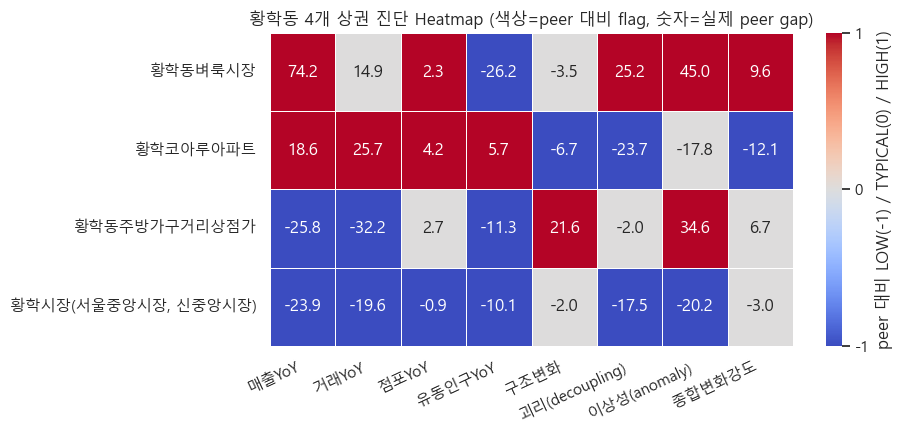

In [17]:
HEATMAP_METRICS = PERF_METRICS + AI_SIGNAL_METRICS
HEATMAP_LABELS_KR = {
    "sales_yoy": "매출YoY", "transactions_yoy": "거래YoY", "stores_yoy": "점포YoY",
    "population_yoy": "유동인구YoY", "structural_change_score": "구조변화",
    "decoupling_score": "괴리(decoupling)", "anomaly_percentile": "이상성(anomaly)",
    "change_intensity_score": "종합변화강도",
}
FLAG_TO_NUM = {"HIGH": 1, "TYPICAL": 0, "LOW": -1, "NA": np.nan}

area_names = [HWANGHAK_NAME_MAP[c] for c in HWANGHAK_CODES]
heat_flag = pd.DataFrame(
    {HEATMAP_LABELS_KR[m]: [FLAG_TO_NUM[bm.loc[c, f"{m}_peer_flag"]] for c in HWANGHAK_CODES] for m in HEATMAP_METRICS},
    index=area_names,
)
heat_gap = pd.DataFrame(
    {HEATMAP_LABELS_KR[m]: [bm.loc[c, f"{m}_peer_gap"] for c in HWANGHAK_CODES] for m in HEATMAP_METRICS},
    index=area_names,
)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
sns.heatmap(
    heat_flag, annot=heat_gap.round(1), fmt=".1f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
    cbar_kws={"label": "peer 대비 LOW(-1) / TYPICAL(0) / HIGH(1)", "ticks": [-1, 0, 1]},
    linewidths=0.6, linecolor="white", ax=ax,
)
ax.set_title("황학동 4개 상권 진단 Heatmap (색상=peer 대비 flag, 숫자=실제 peer gap)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 16. Strategy Priority 참고 Matrix (Figure B)

x축은 13절의 성과 악화 축 계산에 쓰인 PERF_METRICS LOW 개수(0~4), y축은 구조 변화·이상성 축에 쓰인 4개 지표
(`structural_change_score`, `change_intensity_score`, `decoupling_score`, `anomaly_percentile`) 중
`peer_flag == HIGH`인 개수(0~4)다. 둘 다 이미 계산된 `peer_flag`를 세는 것뿐이며 새로운 가중치를 도입하지
않는다. 점선은 시각적 참고선일 뿐이며, 실제 정책 우선순위는 13절의 규칙표를 따른다.

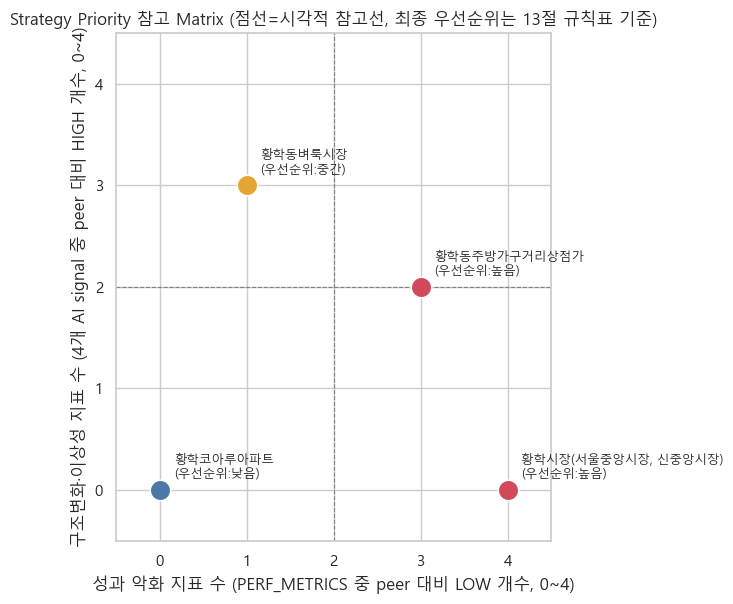

In [18]:
PRIORITY_COLORS = {"높음": "#d1495b", "중간": "#e6a532", "낮음": "#4c78a8"}

fig, ax = plt.subplots(figsize=(6.8, 6.2))
for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    x = sum(rec[f"{m}_peer_flag"] == "LOW" for m in PERF_METRICS)
    y = sum(rec[f"{m}_peer_flag"] == "HIGH" for m in
            ["structural_change_score", "change_intensity_score", "decoupling_score", "anomaly_percentile"])
    priority = priority_map[c]
    ax.scatter(x, y, s=220, color=PRIORITY_COLORS[priority], edgecolor="white", linewidth=1.2, zorder=3)
    ax.annotate(f"{HWANGHAK_NAME_MAP[c]}\n(우선순위:{priority})", (x, y), textcoords="offset points",
                xytext=(10, 8), fontsize=9)

ax.axvline(2, color="grey", linestyle="--", linewidth=0.8, zorder=1)
ax.axhline(2, color="grey", linestyle="--", linewidth=0.8, zorder=1)
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 4.5)
ax.set_xlabel("성과 악화 지표 수 (PERF_METRICS 중 peer 대비 LOW 개수, 0~4)")
ax.set_ylabel("구조변화·이상성 지표 수 (4개 AI signal 중 peer 대비 HIGH 개수, 0~4)")
ax.set_title("Strategy Priority 참고 Matrix (점선=시각적 참고선, 최종 우선순위는 13절 규칙표 기준)")
plt.tight_layout()
plt.show()

## 17. 데이터 근거 · 진단 · 정책 제안의 경계, 그리고 AI 활용 구조

**데이터가 직접 보여주는 것**(예: 매출 감소, peer보다 낮은 거래 성장률, 높은 anomaly)과 **데이터에서 추론한
진단**(예: 구조 변화형, 동반 하락형), **정책적 제안**(예: 전문상권 브랜딩, 공동 마케팅)은 서로 다른 확실성을
가진다. 이 노트북은 정책 제안을 데이터의 확정적 사실처럼 표현하지 않는다.

이번 프로젝트의 AI/데이터 활용 흐름은 다음과 같다.

```text
Isolation Forest (05)
   -> 이상 변화 탐지

Nearest Neighbor (06)
   -> 구조적 유사 상권 탐색

Peer Benchmark (06)
   -> 상대적 성과 차이 진단

Rule-based Classification (07, 9절)
   -> 문제 유형 및 정책 우선순위 판정

Deterministic Strategy Mapping (07, 12절)
   -> 데이터 근거 기반 전략 후보 제안
```

AI/ML이 정책을 직접 생성하거나 전략을 만든 것이 아니다. **AI/ML 기반 이상탐지와 유사 상권 분석을 이용해
상권의 이상 변화와 상대적 문제를 탐지하고, 그 결과를 설명 가능한 규칙 기반 진단 및 전략 추천 체계로
연결하였다.** 즉 Isolation Forest와 Nearest Neighbor가 분석 신호(anomaly, peer gap 등)를 생성하고, 최종
전략은 그 신호와 상권별 domain feature를 활용한 deterministic rule-based recommendation(`BASE_STRATEGY_MAP`
+ `DOMAIN_STRATEGY_RULES`)으로 도출한다. 이 노트북은 OpenAI/Claude 등 외부 LLM API를 호출하지 않는다
(재현성, 비용, 실행 환경 의존성, 매번 달라질 수 있는 결과를 피하기 위함). 전략/KPI mapping은 노트북 안에
코드로 명시되어 있어 누구나 그대로 재현하고 검토할 수 있다.

## 18. 결과 CSV 저장

Tableau/발표 자료에서 바로 활용할 수 있도록, 한 행 = 황학동 상권 1개 형태로 저장한다. 전략/근거/KPI는 Python
list가 아니라 개별 컬럼(`strategy_1~3` + `strategy_basis_1~3`, `outcome_kpi_1~3`, `diagnostic_kpi_1~3`)으로
풀어서 저장한다. `peer_comparability_level`/`peer_comparability_note`도 함께 저장해, 결과를 보는 사람이
`peer_gap`을 얼마나 신뢰해 읽어야 하는지 판단할 수 있게 한다.

In [19]:
records = []
for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    d_type = diagnosis_type_map[c]
    strategies, bases, domain_used = build_strategies(rec, d_type)
    outcome_kpis, diagnostic_kpis = build_kpis(d_type, domain_used)
    issues = main_issues[c]
    comp_level = peer_comparability_level(rec["nearest_peer_distance_percentile"])
    comp_note = peer_comparability_note(comp_level)
    records.append({
        "상권_코드": c,
        "상권_코드_명": HWANGHAK_NAME_MAP[c],
        "상권_구분_코드_명": HWANGHAK_TYPE_MAP[c],
        "diagnosis_type": d_type,
        "priority_level": priority_map[c],
        "performance_axis": performance_axis(rec),
        "structural_axis": structural_axis(rec),
        "anomaly_axis": anomaly_axis(rec),
        "peer_comparability_level": comp_level,
        "peer_comparability_note": comp_note,
        "main_issue_1": issues[0],
        "main_issue_2": issues[1],
        "strategy_1": strategies[0], "strategy_basis_1": bases[0],
        "strategy_2": strategies[1], "strategy_basis_2": bases[1],
        "strategy_3": strategies[2], "strategy_basis_3": bases[2],
        "outcome_kpi_1": outcome_kpis[0], "outcome_kpi_2": outcome_kpis[1], "outcome_kpi_3": outcome_kpis[2],
        "diagnostic_kpi_1": diagnostic_kpis[0], "diagnostic_kpi_2": diagnostic_kpis[1],
        "diagnostic_kpi_3": diagnostic_kpis[2],
        "sales_yoy": rec["sales_yoy"],
        "transactions_yoy": rec["transactions_yoy"],
        "stores_yoy": rec["stores_yoy"],
        "population_yoy": rec["population_yoy"],
        "sales_yoy_peer_gap": rec["sales_yoy_peer_gap"],
        "transactions_yoy_peer_gap": rec["transactions_yoy_peer_gap"],
        "stores_yoy_peer_gap": rec["stores_yoy_peer_gap"],
        "population_yoy_peer_gap": rec["population_yoy_peer_gap"],
        "structural_change_score": rec["structural_change_score"],
        "decoupling_score": rec["decoupling_score"],
        "anomaly_percentile": rec["anomaly_percentile"],
        "change_intensity_score": rec["change_intensity_score"],
        "instability_score": rec["instability_score"],
        "direction_score": rec["direction_score"],
        "nearest_peer_distance_percentile": rec["nearest_peer_distance_percentile"],
        "representative_peer_1": rec["representative_peer_1"],
        "representative_peer_2": rec["representative_peer_2"],
        "representative_peer_3": rec["representative_peer_3"],
    })

strategy_recommendation_df = pd.DataFrame(records)
print("strategy_recommendation_df shape:", strategy_recommendation_df.shape)
strategy_recommendation_df

strategy_recommendation_df shape: (4, 42)


,상권_코드,상권_코드_명,상권_구분_코드_명,diagnosis_type,priority_level,performance_axis,structural_axis,anomaly_axis,peer_comparability_level,peer_comparability_note,main_issue_1,main_issue_2,strategy_1,strategy_basis_1,strategy_2,strategy_basis_2,strategy_3,strategy_basis_3,outcome_kpi_1,outcome_kpi_2,outcome_kpi_3,diagnostic_kpi_1,diagnostic_kpi_2,diagnostic_kpi_3,sales_yoy,transactions_yoy,stores_yoy,population_yoy,sales_yoy_peer_gap,transactions_yoy_peer_gap,stores_yoy_peer_gap,population_yoy_peer_gap,structural_change_score,decoupling_score,anomaly_percentile,change_intensity_score,instability_score,direction_score,nearest_peer_distance_percentile,representative_peer_1,representative_peer_2,representative_peer_3
0,3110055,황학동벼룩시장,골목상권,매출-유동인구 괴리형,중간,중간,중간,높음,높음,"최근접 peer가 동일 유형 내에서 상대적으로 가까운 편으로, peer 비교 가능성 측면에서 큰 주의 신호는 확인되지 않는다.",유동인구 YoY peer 대비 낮음(peer gap -26.2%p),"이상성(anomaly) peer 대비 높음(peer gap +45.0p, 이례적 신호)",전자상거래 관련 매출 비중이 높은 특성을 활용해 온·오프라인 연계 프로그램의 적용 가능성 검토,"ecommerce_sales_share가 peer 대비 +79.8%p 높게 관측되어, 온라인 채널 매출과 오프라인 방문을 연계할 근거가 있음",주말 매출 집중 특성을 활용한 주말 행사·체험 콘텐츠 강화 검토,"weekend_sales_share가 peer 대비 +47.6%p 높게 관측되어, 주말 매출 집중 특성을 활용한 전략을 검토할 근거가 있음",매출 성과를 실제 방문으로 연결하는 방안 검토,매출-유동인구 괴리형 진단 결과에 따른 기본 전략 방향,population_yoy,sales_yoy,transactions_yoy,decoupling_score,anomaly_percentile,ecommerce_sales_share,74.344454,17.017110,-1.063830,-30.175085,74.232781,14.933522,2.336708,-26.197640,54.393842,79.634010,99.099678,61.177893,49.505828,0.267960,39.334638,대림차이나타운(대림역 12번),망원나들목체육관,도봉구민회관
1,3110057,황학코아루아파트,골목상권,상대적 안정·우위형,낮음,낮음,낮음,낮음,높음,"최근접 peer가 동일 유형 내에서 상대적으로 가까운 편으로, peer 비교 가능성 측면에서 큰 주의 신호는 확인되지 않는다.",핵심 성과지표(매출/거래/점포/유동인구)가 모두 peer 대비 양호하거나 유사해 데이터상 뚜렷한 문제는 확인되지 않음. 관리 포인트: top1_industry_share가 peer 대비 +15.2%p 높게 관...,-,단일 업종 편중에 따른 위험을 낮추기 위한 업종 다양성/구성 모니터링 검토,"top1_industry_share가 peer 대비 +15.2%p 높게 관측되어, 업종 집중 위험을 모니터링할 근거가 있음",현재의 상대적 경쟁우위 유지,상대적 안정·우위형 진단 결과에 따른 기본 전략 방향,기존 강점 확장 검토,상대적 안정·우위형 진단 결과에 따른 기본 전략 방향,sales_yoy,population_yoy,transactions_yoy,structural_change_score,anomaly_percentile,top1_industry_share,12.866359,19.382366,-0.980392,3.491111,18.630284,25.650223,4.151187,5.698627,37.254650,20.853741,44.372990,37.253173,53.651127,0.559880,15.949119,행당역 2번,경의중앙 신촌역,새터산
2,3130054,황학동주방가구거리상점가,전통시장,구조 변화·업종 재편형,높음,높음,중간,중간,낮음,"최근접 peer도 동일 유형 내에서 상대적으로 먼 편이므로, peer gap을 다른 상권보다 보수적으로 해석할 필요가 있다.",거래건수 YoY peer 대비 낮음(peer gap -32.2%p),"이상성(anomaly) peer 대비 높음(peer gap +34.6p, 이례적 신호)","특화 업종(가구/주방 등) 중심 전문상권 브랜딩, 온라인 카탈로그, B2B 수요 연결 검토","furniture_sales_share가 peer 대비 +56.9%p 높게 관측되어, 특화 업종 기반 전문상권 전략을 검토할 근거가 있음",단일 업종 편중에 따른 위험을 낮추기 위한 업종 다양성/구성 모니터링 검토,"top1_industry_share가 peer 대비 +5.6%p 높게 관측되어, 업종 집중 위험을 모니터링할 근거가 있음",상권 포지셔닝 재정립 검토,구조 변화·업종 재편형 진단 결과에 따른 기본 전략 방향,transactions_yoy,sales_yoy,stores_yoy,structural_change_score,anomaly_percentile,furniture_sales_share,-14.226812,-24.712467,2.577320,-18.050908,-25.842440,-32.248968,2.718673,-11.268349,70.891597,55.206432,88.810289,58.484761,49.356255,-0.379520,90.942029,영등포전통시장,통인시장,청량종합도매시장
3,3130055,"황학시장(서울중앙시장, 신중앙시장)",전통시장,동반 하락형,높음,높음,낮음,낮음,높음,"최근접 peer가 동일 유형 내에서 상대적으로 가까운 편으로, peer 비교 가능성 측면에서 큰 주의 신호는 확인되지 않는다.",매출 YoY peer 대비 낮음(peer gap -23.9%p),거래건수 YoY peer 대비 낮음(peer gap -19.6%p),생활권 수요 회복 검토,동반 하락형 진단 결과에 따른 기본 전략 방향,방문 및 구매 전환 확대 검토,동반 하락형 진단 결과에 따른 기본 전략 방향,점포 경쟁력 개선 검토,동반 하락형 진단 결과에 따른 기본 전략 방향,population_yoy,sales_yoy,stores_yoy,structural_change_score,anomaly_percentile,change_intensity_score,-18.098214,-15.159699,-2.732240,-14.131048,-23.941053,-19.581592,-0.903988,-10.077211,39.910199,31.591052,12.347267,42.084980,54.753691,-0.541594,27.173913,대조시장,동화동 골목형상점가,상계중앙시장


In [20]:
strategy_recommendation_df.to_csv(STRATEGY_OUT_PATH, encoding="utf-8-sig", index=False)
print("저장 완료:", STRATEGY_OUT_PATH, strategy_recommendation_df.shape)

저장 완료: ..\data\processed\hwanghak_strategy_recommendation.csv (4, 42)


## 19. Data Dictionary 저장

In [21]:
STRATEGY_DICTIONARY_ROWS = [
    dict(column_pattern="diagnosis_type", category="진단",
         definition="09절 rule-based classification 결과(peer_flag 조합 기준, 이번 개정에서 로직 변경 없음). "
                     "매출-유동인구 괴리형 / 상대적 안정·우위형 / 구조 변화·업종 재편형 / 동반 하락형 / "
                     "복합형(추가 정밀진단 필요) 중 하나",
         interpretation="상권이 어떤 유형의 변화 패턴을 보이는지 요약한 라벨",
         caution="객관적으로 확정된 상권 유형이 아니라 05/06 signal의 peer_flag 조합에 대한 사후 해석이다"),
    dict(column_pattern="priority_level", category="정책 우선순위",
         definition="13절 rule-based priority matrix(성과 악화/구조 변화/이상성 축의 조건문 조합) 결과. 높음/중간/낮음",
         interpretation="현재 데이터상 정책 개입 또는 추가 정밀진단이 상대적으로 더 필요한 정도",
         caution="상권의 절대적인 '좋고 나쁨' 순위가 아니다. peer_comparability_level과 무관하게 결정된다"),
    dict(column_pattern="performance_axis / structural_axis / anomaly_axis", category="정책 우선순위",
         definition="각각 PERF_METRICS의 LOW 개수, {structural_change,change_intensity}의 HIGH 개수, "
                     "{anomaly_percentile,decoupling_score}의 HIGH 개수를 낮음/중간/높음으로 변환한 값",
         interpretation="priority_level을 구성하는 세 축의 개별 판정",
         caution="세 축을 가중합하지 않고 13절의 조건문 규칙으로만 priority_level을 결정한다"),
    dict(column_pattern="peer_comparability_level", category="peer 비교 가능성",
         definition="nearest_peer_distance_percentile을 사람이 해석하기 쉽게 낮음/중간/높음 3구간으로 표현한 값"
                     "(구간 기준: 80/50 percentile, 6-1절 참고)",
         interpretation="동일 상권유형 안에서 해당 target의 최근접 peer distance가 다른 상권에 비해 상대적으로 "
                         "가까운지/먼지에 대한 보조 정보. 낮음일수록(percentile이 높을수록) 최근접 peer가 "
                         "상대적으로 먼 편이었다는 뜻",
         caution="diagnosis_type/priority_level 계산에 사용하지 않는다. 통계적 신뢰도나 모델 confidence가 "
                 "아니라 nearest peer distance의 상대적 위치를 사람이 해석하기 쉽게 표현한 보조 정보다. "
                 "'가까운 peer가 다수 존재한다'거나 '통계적으로 신뢰할 수 있다'는 의미로 확대 해석하지 않는다"),
    dict(column_pattern="peer_comparability_note", category="peer 비교 가능성",
         definition="peer_comparability_level에 대응하는 해석 문장",
         interpretation="peer_comparability_level이 '낮음'인 상권은 peer gap을 보수적으로 해석하라는 안내를 포함한다",
         caution="peer_comparability_level과 마찬가지로 heuristic 해석이며 통계적 신뢰구간이나 confidence가 아니다"),
    dict(column_pattern="main_issue_1 / main_issue_2", category="진단",
         definition="10절에서 PERF_METRICS(LOW)와 AI_SIGNAL_METRICS(HIGH) 각 그룹에서 |peer_gap|이 가장 큰 "
                     "지표를 우선 채택해 구성한 상권별 핵심 문제(최대 2개). 문제 flag가 없는 상권은 관리 포인트로 대체",
         interpretation="해당 상권에서 가장 먼저 확인해야 할 문제 또는 관리 포인트",
         caution="모든 문제를 나열한 것이 아니라 최대 2개로 압축한 값이다. 전체 지표는 diagnostic_table 참고. "
                 "top1_industry_share 등 0~1 비율(share) 지표의 gap은 format_gap_pp()로 %p 단위로 표시한다"),
    dict(column_pattern="strategy_1 / strategy_2 / strategy_3", category="전략",
         definition="12절 BASE_STRATEGY_MAP(diagnosis_type 기준 일반 전략)과 DOMAIN_STRATEGY_RULES(domain "
                     "feature의 peer_gap이 DOMAIN_GAP_THRESHOLD=0.05, 즉 5 percentage point를 초과할 때 "
                     "채택되는 상권 맞춤 전략)을 결합해 구성한 전략 3개. domain 맞춤 전략이 2개 이상 해당하면 "
                     "peer_gap이 큰 순서대로 최대 2개를 선택한다(DOMAIN_STRATEGY_RULES에 적힌 순서가 아니다)",
         interpretation="진단 유형과 상권의 domain 특성에 따라 고려할 수 있는 전략 방향(실행 옵션)",
         caution="정책 효과가 검증된 값이 아니라 데이터 기반 진단에서 도출된 정책 후보이며, 시행 전 현장 "
                 "검증이 필요하다. 상권명을 조건으로 사용하지 않고 peer_gap 값으로만 결정한다. "
                 "DOMAIN_GAP_THRESHOLD는 통계적 유의성 기준이 아니라 전략을 구체화하기 위한 실무적 heuristic이며, "
                 "이 기준을 넘는다고 해당 domain 특성이 인과적으로 중요하다는 의미는 아니다"),
    dict(column_pattern="strategy_basis_1 / strategy_basis_2 / strategy_basis_3", category="전략",
         definition="같은 순번의 strategy가 어떤 observed data/peer 비교에서 채택되었는지 기록한 근거 문장. "
                     "domain 맞춤 전략의 근거는 domain feature(0~1 비율)의 peer_gap을 format_gap_pp()로 "
                     "×100하여 %p로 표시한다(예: gap=0.798 -> +79.8%p). 내부 비교/정렬에는 항상 0~1 원값을 사용한다",
         interpretation="전략 추천의 설명 가능성을 높이기 위한 근거. domain 맞춤 전략은 해당 metric의 "
                         "peer_gap을, 기본 전략은 diagnosis_type을 근거로 표기한다",
         caution="상관관계(동시 관측)를 서술한 것이며 인과관계를 단정하지 않는다"),
    dict(column_pattern="outcome_kpi_1 / outcome_kpi_2 / outcome_kpi_3", category="KPI",
         definition="12절 OUTCOME_KPI_MAP에서 diagnosis_type에 대응하는, PERF_METRICS 중에서 선택한 결과지표 3개",
         interpretation="정책 실행 후 실제 성과 변화(매출/거래/점포/유동인구)를 추적하기 위한 지표",
         caution="새로 정의한 지표가 아니며, 목표 수치나 기대 개선폭을 의미하지 않는다"),
    dict(column_pattern="diagnostic_kpi_1 / diagnostic_kpi_2 / diagnostic_kpi_3", category="KPI",
         definition="12절 DIAGNOSTIC_KPI_BASE_MAP(AI_SIGNAL_METRICS 2개)에, domain 맞춤 전략이 채택된 경우 "
                     "해당 domain metric을, 채택되지 않은 경우 change_intensity_score를 3번째로 추가한 지표 3개",
         interpretation="이상성, 구조 변화, 괴리, 업종 집중 등 문제 상태를 지속적으로 모니터링하는 진단/모니터링 지표",
         caution="실제로 선택된 전략과 관련 있는 domain metric만 포함한다(예: furniture 전략이 선택되지 않았는데 "
                 "furniture_sales_share를 넣지 않는다). outcome_kpi와 역할이 다르다(결과 vs 상태 모니터링)"),
]

for m in ["sales_yoy", "transactions_yoy", "stores_yoy", "population_yoy", "structural_change_score",
          "decoupling_score", "anomaly_percentile", "change_intensity_score", "instability_score",
          "direction_score", "nearest_peer_distance_percentile"]:
    STRATEGY_DICTIONARY_ROWS.append(dict(
        column_pattern=m, category="05/06 재사용 값",
        definition="05(signal_dictionary.csv) 또는 06(peer_benchmark_dictionary.csv)에서 이미 정의된 값을 그대로 사용",
        interpretation="상세 정의는 signal_dictionary.csv / peer_benchmark_dictionary.csv 참고",
        caution="이 notebook에서 새로 정의한 값이 아니다",
    ))
for m in [f"{base}_peer_gap" for base in ["sales_yoy", "transactions_yoy", "stores_yoy", "population_yoy"]]:
    STRATEGY_DICTIONARY_ROWS.append(dict(
        column_pattern=m, category="06 재사용 값",
        definition="target value - Top10 peer median (06과 동일한 정의). sales_yoy 등은 이미 %(percent) "
                    "단위로 저장되어 있으므로 gap도 %p 단위 그대로 사용한다(0~1 비율 변환 불필요)",
        interpretation="peer 대비 황학동의 상대적 차이(원 단위, %p)",
        caution="양수라고 실제 YoY가 증가했다는 뜻은 아니다(peer보다 덜 감소한 경우도 양수가 된다)",
    ))
STRATEGY_DICTIONARY_ROWS.append(dict(
    column_pattern="representative_peer_1/2/3", category="06 재사용 값",
    definition="06 Nearest Neighbor Top3 peer 이름",
    interpretation="구조적 참고 사례. 성과 비교 기준으로만 사용하며 정책 성공 사례로 해석하지 않는다",
    caution="거리가 가깝다고 인과관계가 있는 것은 아니다",
))

strategy_recommendation_dictionary = pd.DataFrame(STRATEGY_DICTIONARY_ROWS)[
    ["column_pattern", "category", "definition", "interpretation", "caution"]
]
print("strategy_recommendation_dictionary 행 수:", len(strategy_recommendation_dictionary))
strategy_recommendation_dictionary

strategy_recommendation_dictionary 행 수: 26


,column_pattern,category,definition,interpretation,caution
0,diagnosis_type,진단,"09절 rule-based classification 결과(peer_flag 조합 기준, 이번 개정에서 로직 변경 없음). 매출-유동인구 괴리형 / 상대적 안정·우위형 / 구조 변화·업종 재편형 / 동반 하락...",상권이 어떤 유형의 변화 패턴을 보이는지 요약한 라벨,객관적으로 확정된 상권 유형이 아니라 05/06 signal의 peer_flag 조합에 대한 사후 해석이다
1,priority_level,정책 우선순위,13절 rule-based priority matrix(성과 악화/구조 변화/이상성 축의 조건문 조합) 결과. 높음/중간/낮음,현재 데이터상 정책 개입 또는 추가 정밀진단이 상대적으로 더 필요한 정도,상권의 절대적인 '좋고 나쁨' 순위가 아니다. peer_comparability_level과 무관하게 결정된다
2,performance_axis / structural_axis / anomaly_axis,정책 우선순위,"각각 PERF_METRICS의 LOW 개수, {structural_change,change_intensity}의 HIGH 개수, {anomaly_percentile,decoupling_score}의 HIGH ...",priority_level을 구성하는 세 축의 개별 판정,세 축을 가중합하지 않고 13절의 조건문 규칙으로만 priority_level을 결정한다
3,peer_comparability_level,peer 비교 가능성,"nearest_peer_distance_percentile을 사람이 해석하기 쉽게 낮음/중간/높음 3구간으로 표현한 값(구간 기준: 80/50 percentile, 6-1절 참고)",동일 상권유형 안에서 해당 target의 최근접 peer distance가 다른 상권에 비해 상대적으로 가까운지/먼지에 대한 보조 정보. 낮음일수록(percentile이 높을수록) 최근접 peer가 상대적으로...,diagnosis_type/priority_level 계산에 사용하지 않는다. 통계적 신뢰도나 모델 confidence가 아니라 nearest peer distance의 상대적 위치를 사람이 해석하기 쉽게 표...
4,peer_comparability_note,peer 비교 가능성,peer_comparability_level에 대응하는 해석 문장,peer_comparability_level이 '낮음'인 상권은 peer gap을 보수적으로 해석하라는 안내를 포함한다,peer_comparability_level과 마찬가지로 heuristic 해석이며 통계적 신뢰구간이나 confidence가 아니다
5,main_issue_1 / main_issue_2,진단,10절에서 PERF_METRICS(LOW)와 AI_SIGNAL_METRICS(HIGH) 각 그룹에서 |peer_gap|이 가장 큰 지표를 우선 채택해 구성한 상권별 핵심 문제(최대 2개). 문제 flag가 없...,해당 상권에서 가장 먼저 확인해야 할 문제 또는 관리 포인트,모든 문제를 나열한 것이 아니라 최대 2개로 압축한 값이다. 전체 지표는 diagnostic_table 참고. top1_industry_share 등 0~1 비율(share) 지표의 gap은 format_ga...
6,strategy_1 / strategy_2 / strategy_3,전략,12절 BASE_STRATEGY_MAP(diagnosis_type 기준 일반 전략)과 DOMAIN_STRATEGY_RULES(domain feature의 peer_gap이 DOMAIN_GAP_THRESHOLD...,진단 유형과 상권의 domain 특성에 따라 고려할 수 있는 전략 방향(실행 옵션),"정책 효과가 검증된 값이 아니라 데이터 기반 진단에서 도출된 정책 후보이며, 시행 전 현장 검증이 필요하다. 상권명을 조건으로 사용하지 않고 peer_gap 값으로만 결정한다. DOMAIN_GAP_THRESH..."
7,strategy_basis_1 / strategy_basis_2 / strategy_basis_3,전략,같은 순번의 strategy가 어떤 observed data/peer 비교에서 채택되었는지 기록한 근거 문장. domain 맞춤 전략의 근거는 domain feature(0~1 비율)의 peer_gap을 fo...,"전략 추천의 설명 가능성을 높이기 위한 근거. domain 맞춤 전략은 해당 metric의 peer_gap을, 기본 전략은 diagnosis_type을 근거로 표기한다",상관관계(동시 관측)를 서술한 것이며 인과관계를 단정하지 않는다
8,outcome_kpi_1 / outcome_kpi_2 / outcome_kpi_3,KPI,"12절 OUTCOME_KPI_MAP에서 diagnosis_type에 대응하는, PERF_METRICS 중에서 선택한 결과지표 3개",정책 실행 후 실제 성과 변화(매출/거래/점포/유동인구)를 추적하기 위한 지표,"새로 정의한 지표가 아니며, 목표 수치나 기대 개선폭을 의미하지 않는다"
9,diagnostic_kpi_1 / diagnostic_kpi_2 / diagnostic_kpi_3,KPI,"12절 DIAGNOSTIC_KPI_BASE_MAP(AI_SIGNAL_METRICS 2개)에, domain 맞춤 전략이 채택된 경우 해당 domain metric을, 채택되지 않은 경우 change_intens...","이상성, 구조 변화, 괴리, 업종 집중 등 문제 상태를 지속적으로 모니터링하는 진단/모니터링 지표",실제로 선택된 전략과 관련 있는 domain metric만 포함한다(예: furniture 전략이 선택되지 않았는데 furniture_sales_share를 넣지 않는다). outcome_kpi와 역할이 다르...


In [22]:
strategy_recommendation_dictionary.to_csv(STRATEGY_DICT_OUT_PATH, encoding="utf-8-sig", index=False)
print("저장 완료:", STRATEGY_DICT_OUT_PATH, strategy_recommendation_dictionary.shape)

저장 완료: ..\data\processed\strategy_recommendation_dictionary.csv (26, 5)


## 20. Validation

In [23]:
# 상권 수
assert len(HWANGHAK_CODES) == 4, "황학동 target은 정확히 4개여야 합니다."
assert strategy_recommendation_df.shape[0] == 4

# diagnosis / priority 존재 및 회귀 확인(이번 개정으로 기존 결과가 바뀌지 않았는지)
EXPECTED_DIAGNOSIS_TYPE = {
    3110055: "매출-유동인구 괴리형",     # 황학동벼룩시장
    3110057: "상대적 안정·우위형",       # 황학코아루아파트
    3130054: "구조 변화·업종 재편형",     # 황학동주방가구거리상점가
    3130055: "동반 하락형",             # 황학시장
}
EXPECTED_PRIORITY_LEVEL = {3110055: "중간", 3110057: "낮음", 3130054: "높음", 3130055: "높음"}

assert strategy_recommendation_df["diagnosis_type"].notna().all(), "모든 상권에 diagnosis_type이 있어야 합니다."
assert strategy_recommendation_df["priority_level"].isin(["높음", "중간", "낮음"]).all(), \
    "priority_level은 높음/중간/낮음 중 하나여야 합니다."
for c in HWANGHAK_CODES:
    assert diagnosis_type_map[c] == EXPECTED_DIAGNOSIS_TYPE[c], \
        f"{HWANGHAK_NAME_MAP[c]}의 diagnosis_type이 기존 결과와 달라졌습니다: {diagnosis_type_map[c]}"
    assert priority_map[c] == EXPECTED_PRIORITY_LEVEL[c], \
        f"{HWANGHAK_NAME_MAP[c]}의 priority_level이 기존 결과와 달라졌습니다: {priority_map[c]}"
print("기존 diagnosis_type/priority_level이 이번 개정에서도 그대로 유지되었음을 확인했습니다.")

# strategy / basis / KPI 존재
for i in (1, 2, 3):
    assert strategy_recommendation_df[f"strategy_{i}"].notna().all(), f"strategy_{i}가 모든 상권에 있어야 합니다."
    assert strategy_recommendation_df[f"strategy_basis_{i}"].notna().all(), \
        f"strategy_basis_{i}가 모든 상권에 있어야 합니다."
assert strategy_recommendation_df["outcome_kpi_1"].notna().all(), "각 상권에 최소 1개 이상의 outcome KPI가 있어야 합니다."
assert strategy_recommendation_df["diagnostic_kpi_1"].notna().all(), "각 상권에 최소 1개 이상의 diagnostic KPI가 있어야 합니다."
assert strategy_recommendation_df["main_issue_1"].notna().all(), "각 상권에 핵심 문제(또는 관리포인트)가 있어야 합니다."

# 모든 KPI가 실제 peer_benchmark(bm) 컬럼에 존재하는지 확인
for i in (1, 2, 3):
    for kpi_col in (f"outcome_kpi_{i}", f"diagnostic_kpi_{i}"):
        for kpi_name in strategy_recommendation_df[kpi_col]:
            assert kpi_name in bm.columns, f"{kpi_name}가 hwanghak_peer_benchmark.csv 컬럼에 없습니다."
print("모든 outcome/diagnostic KPI가 hwanghak_peer_benchmark.csv의 실제 컬럼임을 확인했습니다.")

# peer_comparability 결측 없음
assert strategy_recommendation_df["peer_comparability_level"].notna().all()
assert strategy_recommendation_df["peer_comparability_note"].notna().all()
assert strategy_recommendation_df["peer_comparability_level"].isin(["높음", "중간", "낮음"]).all()

# 전략 생성 규칙(BASE_STRATEGY_MAP/DOMAIN_STRATEGY_RULES) 자체에 상권명이 하드코딩되지 않았는지 확인
# (출력 문장 안에 상권명이 표시되는 것은 당연히 허용되며, 여기서는 규칙 정의만 검사한다)
_rule_texts = []
for lst in BASE_STRATEGY_MAP.values():
    _rule_texts += [e["text"] for e in lst]
_rule_texts += [r["strategy"] for r in DOMAIN_STRATEGY_RULES] + [r["basis"] for r in DOMAIN_STRATEGY_RULES]
assert not any(area_name in text for area_name in HWANGHAK_NAME_MAP.values() for text in _rule_texts), \
    "전략 생성 규칙(BASE_STRATEGY_MAP/DOMAIN_STRATEGY_RULES)에 상권명이 하드코딩되어 있습니다."
print("전략 생성 규칙에 상권명이 하드코딩되지 않았음을 확인했습니다.")

# format_gap_pp 단위 변환(0~1 비율 -> %p) 검증
assert format_gap_pp(0.05) == "+5.0%p"
assert format_gap_pp(-0.123) == "-12.3%p"
print("format_gap_pp의 0~1 비율 -> %p 단위 변환을 확인했습니다.")

# domain strategy 선택이 gap 내림차순인지 검증(domain hit가 2개 이상인 상권에 한함)
_checked_any_multi_hit = False
for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    hits = find_domain_hits(rec)
    if len(hits) >= 2:
        _checked_any_multi_hit = True
        selected_gaps = [h["gap"] for h in hits[:2]]
        assert selected_gaps == sorted(selected_gaps, reverse=True), \
            f"{HWANGHAK_NAME_MAP[c]}의 domain strategy가 gap 내림차순으로 선택되지 않았습니다."
if _checked_any_multi_hit:
    print("domain hit가 2개 이상인 상권에서 domain strategy가 gap 내림차순으로 선택되었음을 확인했습니다.")
else:
    print("domain hit가 2개 이상인 상권이 없어 gap 정렬 검증은 이번 실행에서 해당 사항이 없습니다.")

# key 중복 확인
assert not strategy_recommendation_df["상권_코드"].duplicated().any(), "상권_코드 중복이 없어야 합니다."
assert strategy_recommendation_df["상권_코드"].nunique() == 4

# NaN / inf 확인 (수치형 컬럼만)
numeric_cols = strategy_recommendation_df.select_dtypes(include=[np.number]).columns
na_report = strategy_recommendation_df[numeric_cols].isna().sum()
na_report = na_report[na_report > 0]
assert len(na_report) == 0, f"수치형 컬럼에 예상치 못한 NaN이 있습니다: {na_report.to_dict()}"

inf_report = np.isinf(strategy_recommendation_df[numeric_cols]).sum()
inf_report = inf_report[inf_report > 0]
assert len(inf_report) == 0, f"inf가 있는 컬럼: {inf_report.to_dict()}"

print("\n모든 validation을 통과했습니다.")
print(" - 상권 수:", strategy_recommendation_df.shape[0])
print(" - diagnosis_type:", strategy_recommendation_df["diagnosis_type"].tolist())
print(" - priority_level:", strategy_recommendation_df["priority_level"].tolist())

기존 diagnosis_type/priority_level이 이번 개정에서도 그대로 유지되었음을 확인했습니다.
모든 outcome/diagnostic KPI가 hwanghak_peer_benchmark.csv의 실제 컬럼임을 확인했습니다.
전략 생성 규칙에 상권명이 하드코딩되지 않았음을 확인했습니다.
format_gap_pp의 0~1 비율 -> %p 단위 변환을 확인했습니다.
domain hit가 2개 이상인 상권에서 domain strategy가 gap 내림차순으로 선택되었음을 확인했습니다.

모든 validation을 통과했습니다.
 - 상권 수: 4
 - diagnosis_type: ['매출-유동인구 괴리형', '상대적 안정·우위형', '구조 변화·업종 재편형', '동반 하락형']
 - priority_level: ['중간', '낮음', '높음', '높음']


In [24]:
reloaded = pd.read_csv(STRATEGY_OUT_PATH, encoding="utf-8-sig")
reloaded_dict = pd.read_csv(STRATEGY_DICT_OUT_PATH, encoding="utf-8-sig")

print("재로드한 CSV row 수:", reloaded.shape[0], " column 수:", reloaded.shape[1])
assert reloaded.shape[0] == 4
assert reloaded.shape[1] == strategy_recommendation_df.shape[1]
assert list(reloaded.columns) == list(strategy_recommendation_df.columns), "저장 전후 컬럼 구성이 동일해야 합니다."
assert reloaded["상권_코드"].nunique() == 4, "재로드 후 상권_코드가 4개의 고유값을 가져야 합니다."
assert set(reloaded["상권_코드"]) == set(HWANGHAK_CODES)
for col in ["peer_comparability_level", "peer_comparability_note",
            "strategy_basis_1", "strategy_basis_2", "strategy_basis_3",
            "outcome_kpi_1", "diagnostic_kpi_1"]:
    assert col in reloaded.columns, f"{col} 컬럼이 저장된 CSV에 있어야 합니다."
assert reloaded_dict.shape[0] == strategy_recommendation_dictionary.shape[0]

print("저장 -> 재로드 검증 통과: row/column/상권_코드 unique, 신규 컬럼 존재 모두 일치합니다.")

재로드한 CSV row 수: 4  column 수: 42
저장 -> 재로드 검증 통과: row/column/상권_코드 unique, 신규 컬럼 존재 모두 일치합니다.


## 21. 결과 요약

In [25]:
print("=== 07_strategy_recommendation.ipynb 실행 결과 요약 ===")
print("기준 분기:", to_quarter_label(LATEST_QUARTER))
print()

for c in HWANGHAK_CODES:
    rec = bm.loc[c]
    d_type = diagnosis_type_map[c]
    strategies, bases, domain_used = build_strategies(rec, d_type)
    outcome_kpis, diagnostic_kpis = build_kpis(d_type, domain_used)
    comp_level = peer_comparability_level(rec["nearest_peer_distance_percentile"])
    comp_note = peer_comparability_note(comp_level)

    print(f"[{HWANGHAK_NAME_MAP[c]}]")
    print(f"진단 유형: {d_type}")
    print(f"정책 우선순위: {priority_map[c]} "
          f"(성과악화={performance_axis(rec)}, 구조변화={structural_axis(rec)}, 이상성={anomaly_axis(rec)})")
    print()
    print(f"Peer 비교 가능성: {comp_level}")
    print(f"NN distance percentile: {rec['nearest_peer_distance_percentile']:.1f}")
    print(f"해석 주의사항: {comp_note}")
    print()
    print(f"핵심 문제 1: {main_issues[c][0]}")
    print(f"핵심 문제 2: {main_issues[c][1]}")
    print()
    for i, (s, b) in enumerate(zip(strategies, bases), start=1):
        print(f"전략 {i}: {s}")
        print(f"  근거: {b}")
    print()
    print("Outcome KPI:", outcome_kpis)
    print("Diagnostic/Monitoring KPI:", diagnostic_kpis)
    print("=" * 70)

print("\n저장 파일:")
print(" -", STRATEGY_OUT_PATH, strategy_recommendation_df.shape)
print(" -", STRATEGY_DICT_OUT_PATH, strategy_recommendation_dictionary.shape)

=== 07_strategy_recommendation.ipynb 실행 결과 요약 ===
기준 분기: 2025Q4

[황학동벼룩시장]
진단 유형: 매출-유동인구 괴리형
정책 우선순위: 중간 (성과악화=중간, 구조변화=중간, 이상성=높음)

Peer 비교 가능성: 높음
NN distance percentile: 39.3
해석 주의사항: 최근접 peer가 동일 유형 내에서 상대적으로 가까운 편으로, peer 비교 가능성 측면에서 큰 주의 신호는 확인되지 않는다.

핵심 문제 1: 유동인구 YoY peer 대비 낮음(peer gap -26.2%p)
핵심 문제 2: 이상성(anomaly) peer 대비 높음(peer gap +45.0p, 이례적 신호)

전략 1: 전자상거래 관련 매출 비중이 높은 특성을 활용해 온·오프라인 연계 프로그램의 적용 가능성 검토
  근거: ecommerce_sales_share가 peer 대비 +79.8%p 높게 관측되어, 온라인 채널 매출과 오프라인 방문을 연계할 근거가 있음
전략 2: 주말 매출 집중 특성을 활용한 주말 행사·체험 콘텐츠 강화 검토
  근거: weekend_sales_share가 peer 대비 +47.6%p 높게 관측되어, 주말 매출 집중 특성을 활용한 전략을 검토할 근거가 있음
전략 3: 매출 성과를 실제 방문으로 연결하는 방안 검토
  근거: 매출-유동인구 괴리형 진단 결과에 따른 기본 전략 방향

Outcome KPI: ['population_yoy', 'sales_yoy', 'transactions_yoy']
Diagnostic/Monitoring KPI: ['decoupling_score', 'anomaly_percentile', 'ecommerce_sales_share']
[황학코아루아파트]
진단 유형: 상대적 안정·우위형
정책 우선순위: 낮음 (성과악화=낮음, 구조변화=낮음, 이상성=낮음)

Peer 비교 가능성: 높음
NN distance percentile: 15.9
해석 주의사항: 최근접 peer가 동

## 결과 요약 및 한계

### 1. 황학동 전체

황학동 4개 상권은 09절의 rule-based classification 결과 4가지 서로 다른 진단 유형(매출-유동인구 괴리형,
상대적 안정·우위형, 구조 변화·업종 재편형, 동반 하락형)으로 나뉘었다. 즉, 같은 행정동 안에 있더라도 peer
benchmark 기준으로 보면 매출이 오히려 peer보다 크게 증가한 상권(황학동벼룩시장)과 4개 핵심 성과지표가 모두
peer보다 낮은 상권(황학시장)이 공존한다. **황학동 전체를 하나의 정책으로 다루기보다, 상권별 문제 유형에 따른
차별화 전략이 필요하다**는 결론이 데이터로 지지된다.

### 2. 상권별 최종 진단

- **황학동벼룩시장(매출-유동인구 괴리형)**: 매출 YoY가 peer 대비 크게 높지만(절대 증가 + peer 대비 상대적
  우위) 유동인구 YoY는 peer보다 뚜렷하게 낮다(절대 감소 + peer 대비 열위). decoupling_score와
  anomaly_percentile이 모두 peer 대비 HIGH로 관측되며, ecommerce_sales_share 역시 peer보다 높은 수준으로
  동시에 관측된다. 매출 증가, 유동인구 감소, 높은 ecommerce 비중이 동시에 나타난다는 것이지 이 중 하나가
  다른 하나의 원인이라고 확인된 것은 아니며, 온라인 채널 성과와 오프라인 방문 간 연결을 추가로 점검할
  근거로 활용한다.
- **황학코아루아파트(상대적 안정·우위형)**: 매출/거래/유동인구/점포수 YoY가 모두 peer 대비 양호하거나 유사하고,
  structural_change_score와 anomaly_percentile 모두 peer 대비 높지 않다. 다만 top1_industry_share(한식 업종
  비중)가 peer 대비 높은 수준으로 관측되어 단일 업종 의존 모니터링이 관리 포인트다.
- **황학동주방가구거리상점가(구조 변화·업종 재편형)**: 매출/거래/유동인구 YoY가 모두 peer 대비 낮고,
  structural_change_score와 anomaly_percentile이 모두 peer 대비 HIGH로 관측되어 상권 구조 변화 가능성을
  추가로 점검할 필요가 있음을 시사한다. furniture_sales_share 역시 peer보다 높은 수준으로 함께 관측되어
  특화 업종에 대한 의존도가 있는 것으로 보인다. 다만 이 상권은 `peer_comparability_level`이 '낮음'(NN
  distance percentile 90.9)이라, 위 peer_gap 수치들은 다른 상권보다 보수적으로 해석할 필요가 있다.
- **황학시장(동반 하락형)**: 매출/거래/점포수/유동인구 YoY가 모두 peer 대비 낮지만, structural_change_score와
  anomaly_percentile은 peer 대비 특별히 높지 않다(오히려 anomaly는 peer보다 낮은 편). 특정 이상 신호라기보다
  여러 핵심 성과지표가 동시에, 광범위하게 낮게 관측되는 패턴에 가깝다.

### 3. 정책 우선순위

13절의 rule-based priority matrix 결과를 근거와 함께 제시한다(가중합 점수가 아닌 조건문 규칙 기반).
우선순위는 상권의 절대적 우열이 아니라 **정책 개입 또는 추가 정밀진단의 상대적 필요성**을 의미한다. 성과
악화 축이 높은(핵심 성과지표 다수가 peer 대비 LOW) 상권은 우선순위 '높음'으로, headline 성과는 양호하지만
이상성 신호가 큰 상권은 '중간'(정밀진단 우선)으로, 세 축 모두 낮은 상권은 '낮음'으로 분류된다. 이 판정 방식과
4개 상권의 결과는 이번 개정에서도 변경하지 않았다(20절 validation에서 회귀 여부를 확인한다).

### 4. 상권별 전략

12절의 `BASE_STRATEGY_MAP`(diagnosis_type 기준 일반 전략)과 `DOMAIN_STRATEGY_RULES`(domain feature의
peer_gap이 뚜렷할 때, gap이 큰 순서로 채택되는 상권 맞춤 전략)을 결합해 상권별 전략 3개와 각 전략의 데이터
근거(`strategy_basis_1~3`)를 코드로 명시했다. 18절에서 저장한 `hwanghak_strategy_recommendation.csv`의
`strategy_1~3`/`strategy_basis_1~3`/`outcome_kpi_1~3`/`diagnostic_kpi_1~3` 컬럼에 상권별로 매핑되어 있다.

### 5. 프로젝트의 AI 활용

`AI 이상탐지(05, Isolation Forest) → peer benchmark(06, Nearest Neighbor) → 문제 유형화(07, rule-based
classification) → 전략 추천(07, BASE_STRATEGY_MAP + DOMAIN_STRATEGY_RULES)`의 흐름으로 이어진다. AI/ML이
정책을 직접 만든 것이 아니라, AI 기반 이상탐지와 유사 상권 분석으로 상권의 이상 변화와 상대적 문제를 탐지하고
그 결과를 설명 가능한 규칙 기반 진단·전략 추천 체계로 연결한 것이다.

### 6. 이번 개정에서 강조하는 원칙

1. **동일 diagnosis_type이라도 domain 특성에 따라 구체적인 전략은 달라질 수 있다.** 예를 들어 같은
   '매출-유동인구 괴리형'이라도 ecommerce 비중이 높은 상권과 그렇지 않은 상권은 domain 맞춤 전략이 달라진다.
   domain 맞춤 전략 후보가 2개 이상이면 규칙이 적힌 순서가 아니라 `{metric}_peer_gap`이 큰 순서로 최대
   2개를 선택한다.
2. **`peer_comparability_level`이 낮은 상권은 peer_gap 해석에 주의해야 한다.** 이 값은 통계적 신뢰도나 모델
   confidence가 아니라 nearest peer distance의 상대적 위치를 사람이 해석하기 쉽게 표현한 보조 정보이며,
   diagnosis_type이나 priority_level 판정에는 사용하지 않는다.
3. **Outcome KPI와 Diagnostic/Monitoring KPI의 역할은 다르다.** Outcome KPI(`sales_yoy` 등)는 정책 실행 후
   실제 성과 변화를 추적하는 지표이고, Diagnostic KPI(`structural_change_score` 등)는 문제 상태 자체를
   지속적으로 모니터링하는 지표다. 두 지표를 하나의 목록으로 섞어 쓰지 않는다.
4. **전략은 정책 효과가 검증된 처방이 아니라 데이터 기반 정책 후보다.** `strategy_basis`는 관측된 상관관계
   (동시 관측, peer 대비 차이)를 서술한 것이며 인과관계를 단정하지 않는다.
5. **실제 실행 전 현장조사·상인 인터뷰·정책 환경 검토가 필요하다.** peer가 구조적으로 유사하다는 것이 정책
   환경까지 동일하다는 의미는 아니다.
6. **`DOMAIN_GAP_THRESHOLD`(0.05, 5 percentage point)는 통계적 유의성 기준이 아니라 전략을 구체화하기 위한
   실무적 heuristic이다.** 이 기준을 넘는다고 해서 해당 domain 특성이 인과적으로 중요하다는 의미는 아니며,
   domain feature는 `diagnosis_type`이나 `priority_level`을 바꾸지 않는다.

### 7. 한계

- **인과관계의 한계**: 현재 데이터는 관찰 데이터이므로, 특정 전략이 실제로 매출 증가를 유발한다고 증명한
  것은 아니다. 이 노트북의 진단/전략 근거 문장은 "원인이다/때문이다"가 아니라 "동시에 관측됨/peer 대비
  높음·낮음/추가 점검이 필요함" 수준의 관측적 표현으로 작성했다.
- **데이터 범위**: 카드 매출/유동인구/점포 데이터만으로 상권의 모든 원인(임대료, 공실, 정책 시행 이력,
  방문객 특성 등)을 설명할 수 없다. 카드 이용객 속성, 관광객 데이터, 임대료, 공실, 점포 개폐업, SNS/리뷰,
  정책 시행 이력 등은 이번 프로젝트 범위에서 새로 수집하지 않았다.
- **Peer benchmark의 한계**: 구조적으로 유사하다는 것이 정책 환경까지 동일하다는 의미는 아니다. 거리가
  가깝다고 인과관계가 있는 것도 아니다. `peer_comparability_level`이 낮은 상권은 이 한계가 더 크게 적용된다.
- **전략 추천의 한계**: 전략은 데이터 기반 진단에서 도출된 **정책 후보**이며, 실제 시행 전 현장 검증이
  필요하다. 근거 없는 정책 효과(예: "몇 %p 개선")를 추정하지 않았다.